VIX downloaded  : 251 trading days
Range           : 2019-01-02 → 2019-12-30
Missing days    : 0
VIX min/max     : 11.54 / 25.45

Percentiles:
   10th : 12.61
   25th : 13.24
   33th : 13.72
   50th : 14.88
   67th : 16.05
   75th : 16.89
   90th : 19.13

GMM components (sorted by mean):
  Component 1: mean=12.99  std=0.65  weight=0.363
  Component 2: mean=15.33  std=0.97  weight=0.355
  Component 3: mean=18.58  std=2.18  weight=0.282

GMM midpoint boundaries : 14.16 / 16.96
33rd / 67th percentile  : 13.72 / 16.05

>>> LOCKED THRESHOLDS: Quiet < 13.7,  Trending < 16.0,  Crash >= 16.0

2019 regime day counts:
  Quiet     : 81 days
  Trending  : 86 days
  Crash     : 84 days


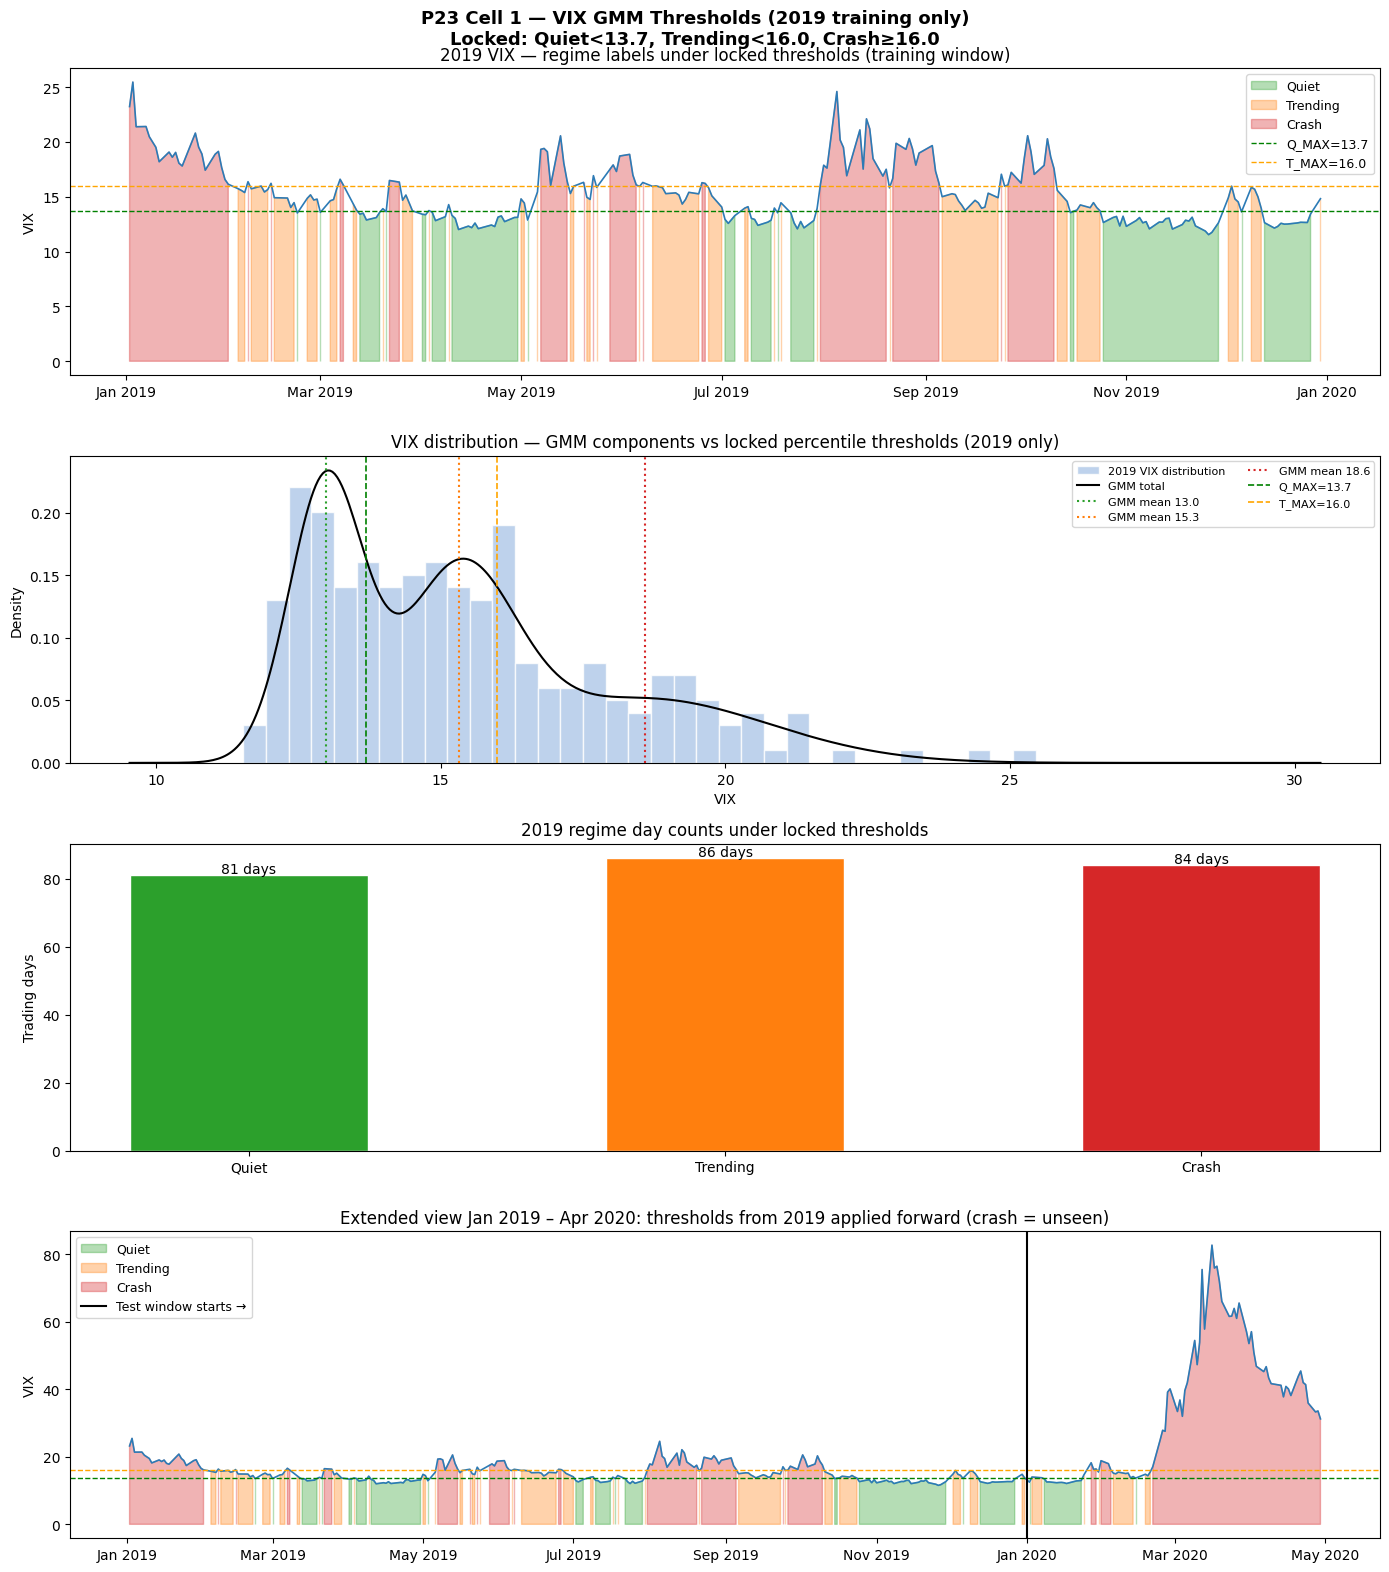


✅ Cell 1 complete.
   Q_MAX = 13.7  |  T_MAX = 16.0
   These thresholds are now locked for all subsequent cells.


In [5]:
# ============================================================
# PROTOTYPE 23 — Cell 1
# VIX GMM Threshold Discovery (Jan 2019 – Dec 2019 ONLY)
# No crash contamination. Thresholds locked before any tick data.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.mixture import GaussianMixture
import yfinance as yf
from pathlib import Path   # ← ADD THIS
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = Path("./p23_output")
OUT_DIR.mkdir(exist_ok=True)

# --- Download 2019 VIX only ---
vix_raw = yf.download("^VIX", start="2019-01-01", end="2019-12-31",
                       auto_adjust=True, progress=False)
vix = vix_raw[["Close"]].copy()
vix.columns = ["vix"]
vix.index = pd.to_datetime(vix.index)
if vix.index.tz is not None:
    vix.index = vix.index.tz_localize(None)

print(f"VIX downloaded  : {len(vix)} trading days")
print(f"Range           : {vix.index[0].date()} → {vix.index[-1].date()}")
print(f"Missing days    : {vix['vix'].isna().sum()}")
print(f"VIX min/max     : {vix['vix'].min():.2f} / {vix['vix'].max():.2f}")
print(f"\nPercentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"  {p:>3}th : {vix['vix'].quantile(p/100):.2f}")

# --- GMM fit ---
vals = vix["vix"].dropna().values.reshape(-1, 1)
gmm  = GaussianMixture(n_components=3, random_state=42, n_init=20)
gmm.fit(vals)

# Sort components by mean
order  = np.argsort(gmm.means_.flatten())
means  = gmm.means_.flatten()[order]
stds   = np.sqrt(gmm.covariances_.flatten()[order])
weights= gmm.weights_[order]

print(f"\nGMM components (sorted by mean):")
for i in range(3):
    print(f"  Component {i+1}: mean={means[i]:.2f}  std={stds[i]:.2f}  weight={weights[i]:.3f}")

# --- Boundary: midpoint between adjacent component means ---
gmm_boundary_1 = (means[0] + means[1]) / 2
gmm_boundary_2 = (means[1] + means[2]) / 2

# --- Percentile boundaries for comparison ---
p33 = vix["vix"].quantile(0.33)
p67 = vix["vix"].quantile(0.67)

print(f"\nGMM midpoint boundaries : {gmm_boundary_1:.2f} / {gmm_boundary_2:.2f}")
print(f"33rd / 67th percentile  : {p33:.2f} / {p67:.2f}")

# --- Decision: use percentile values (data-driven, no rounding) ---
Q_MAX = round(p33, 1)
T_MAX = round(p67, 1)
print(f"\n>>> LOCKED THRESHOLDS: Quiet < {Q_MAX},  Trending < {T_MAX},  Crash >= {T_MAX}")

# --- Apply to 2019 data for sanity check ---
vix["regime"] = np.where(vix["vix"] < Q_MAX,  "Quiet",
                np.where(vix["vix"] < T_MAX, "Trending", "Crash"))

counts = vix["regime"].value_counts().reindex(["Quiet","Trending","Crash"])
print(f"\n2019 regime day counts:")
for r, c in counts.items():
    print(f"  {r:<10}: {int(c)} days")

# --- Now extend view to Jan–Apr 2020 to see where crash falls ---
vix_ext = yf.download("^VIX", start="2019-01-01", end="2020-04-30",
                       auto_adjust=True, progress=False)[["Close"]].copy()
vix_ext.columns = ["vix"]
vix_ext.index = pd.to_datetime(vix_ext.index)
if vix_ext.index.tz is not None:
    vix_ext.index = vix_ext.index.tz_localize(None)

vix_ext["regime"] = np.where(vix_ext["vix"] < Q_MAX,  "Quiet",
                    np.where(vix_ext["vix"] < T_MAX, "Trending", "Crash"))

# --- Figure: 4 panels ---
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle(
    f"P23 Cell 1 — VIX GMM Thresholds (2019 training only)\n"
    f"Locked: Quiet<{Q_MAX}, Trending<{T_MAX}, Crash≥{T_MAX}",
    fontsize=13, fontweight='bold'
)

# Panel 1 — 2019 VIX coloured by regime
ax = axes[0]
for regime, col in colors.items():
    mask = vix["regime"] == regime
    ax.fill_between(vix.index, vix["vix"], where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix.index, vix["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1, label=f"Q_MAX={Q_MAX}")
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1, label=f"T_MAX={T_MAX}")
ax.set_ylabel("VIX")
ax.set_title("2019 VIX — regime labels under locked thresholds (training window)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Panel 2 — GMM distribution
ax = axes[1]
x_range = np.linspace(vals.min()-2, vals.max()+5, 500).reshape(-1, 1)
log_prob = gmm.score_samples(x_range)
ax.hist(vix["vix"].dropna(), bins=35, density=True,
        color="#aec7e8", edgecolor="white", alpha=0.8, label="2019 VIX distribution")
ax.plot(x_range, np.exp(log_prob), color="black", linewidth=1.5, label="GMM total")
comp_colors = ["#2ca02c", "#ff7f0e", "#d62728"]
for i in range(3):
    ax.axvline(means[i], color=comp_colors[i], linestyle=":",
               linewidth=1.5, label=f"GMM mean {means[i]:.1f}")
ax.axvline(Q_MAX, color="green",  linestyle="--", linewidth=1.2, label=f"Q_MAX={Q_MAX}")
ax.axvline(T_MAX, color="orange", linestyle="--", linewidth=1.2, label=f"T_MAX={T_MAX}")
ax.set_xlabel("VIX")
ax.set_ylabel("Density")
ax.set_title("VIX distribution — GMM components vs locked percentile thresholds (2019 only)")
ax.legend(fontsize=8, ncol=2)

# Panel 3 — Day count bar chart
ax = axes[2]
bars = ax.bar(counts.index, counts.values,
              color=[colors[r] for r in counts.index],
              edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{int(val)} days", ha="center", fontsize=10)
ax.set_ylabel("Trading days")
ax.set_title("2019 regime day counts under locked thresholds")

# Panel 4 — Extended view Jan 2019 to Apr 2020 (crash visible but NOT used for thresholds)
ax = axes[3]
for regime, col in colors.items():
    mask = vix_ext["regime"] == regime
    ax.fill_between(vix_ext.index, vix_ext["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix_ext.index, vix_ext["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.axvline(pd.Timestamp("2020-01-01"), color="black", linestyle="-",
           linewidth=1.5, label="Test window starts →")
ax.set_ylabel("VIX")
ax.set_title("Extended view Jan 2019 – Apr 2020: thresholds from 2019 applied forward (crash = unseen)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell1_vix_thresholds.png", dpi=150)
plt.show()

print(f"\n✅ Cell 1 complete.")
print(f"   Q_MAX = {Q_MAX}  |  T_MAX = {T_MAX}")
print(f"   These thresholds are now locked for all subsequent cells.")

Thresholds confirmed: Quiet<13.7, Trending<16.0, Crash>=16.0
VIX window          : 2019-01-02 → 2019-12-30
Regime counts       : {'Trending': 86, 'Crash': 84, 'Quiet': 81}


  QUIET — continuous runs ≥ 5 trading days (2019 only)
       start        end  trading_days   vix_mean  vix_min  vix_max
0 2019-10-25 2019-11-29            25  12.599200    11.54    13.22
1 2019-04-10 2019-04-30            14  12.683571    12.01    13.30
2 2019-12-13 2019-12-27            10  12.601000    12.14    13.43
3 2019-07-22 2019-07-29             6  12.656666    12.07    13.53
4 2019-03-13 2019-03-19             5  13.290000    12.88    13.56
5 2019-07-10 2019-07-16             5  12.778000    12.39    13.03

  TRENDING — continuous runs ≥ 5 trading days (2019 only)
       start        end  trading_days   vix_mean  vix_min  vix_max
0 2019-09-06 2019-09-23            12  14.615000    13.74    15.32
1 2019-06-10 2019-06-24            11  15.380000    14.33    15.99
2 2019-10-17 2019-10-24             6  14.

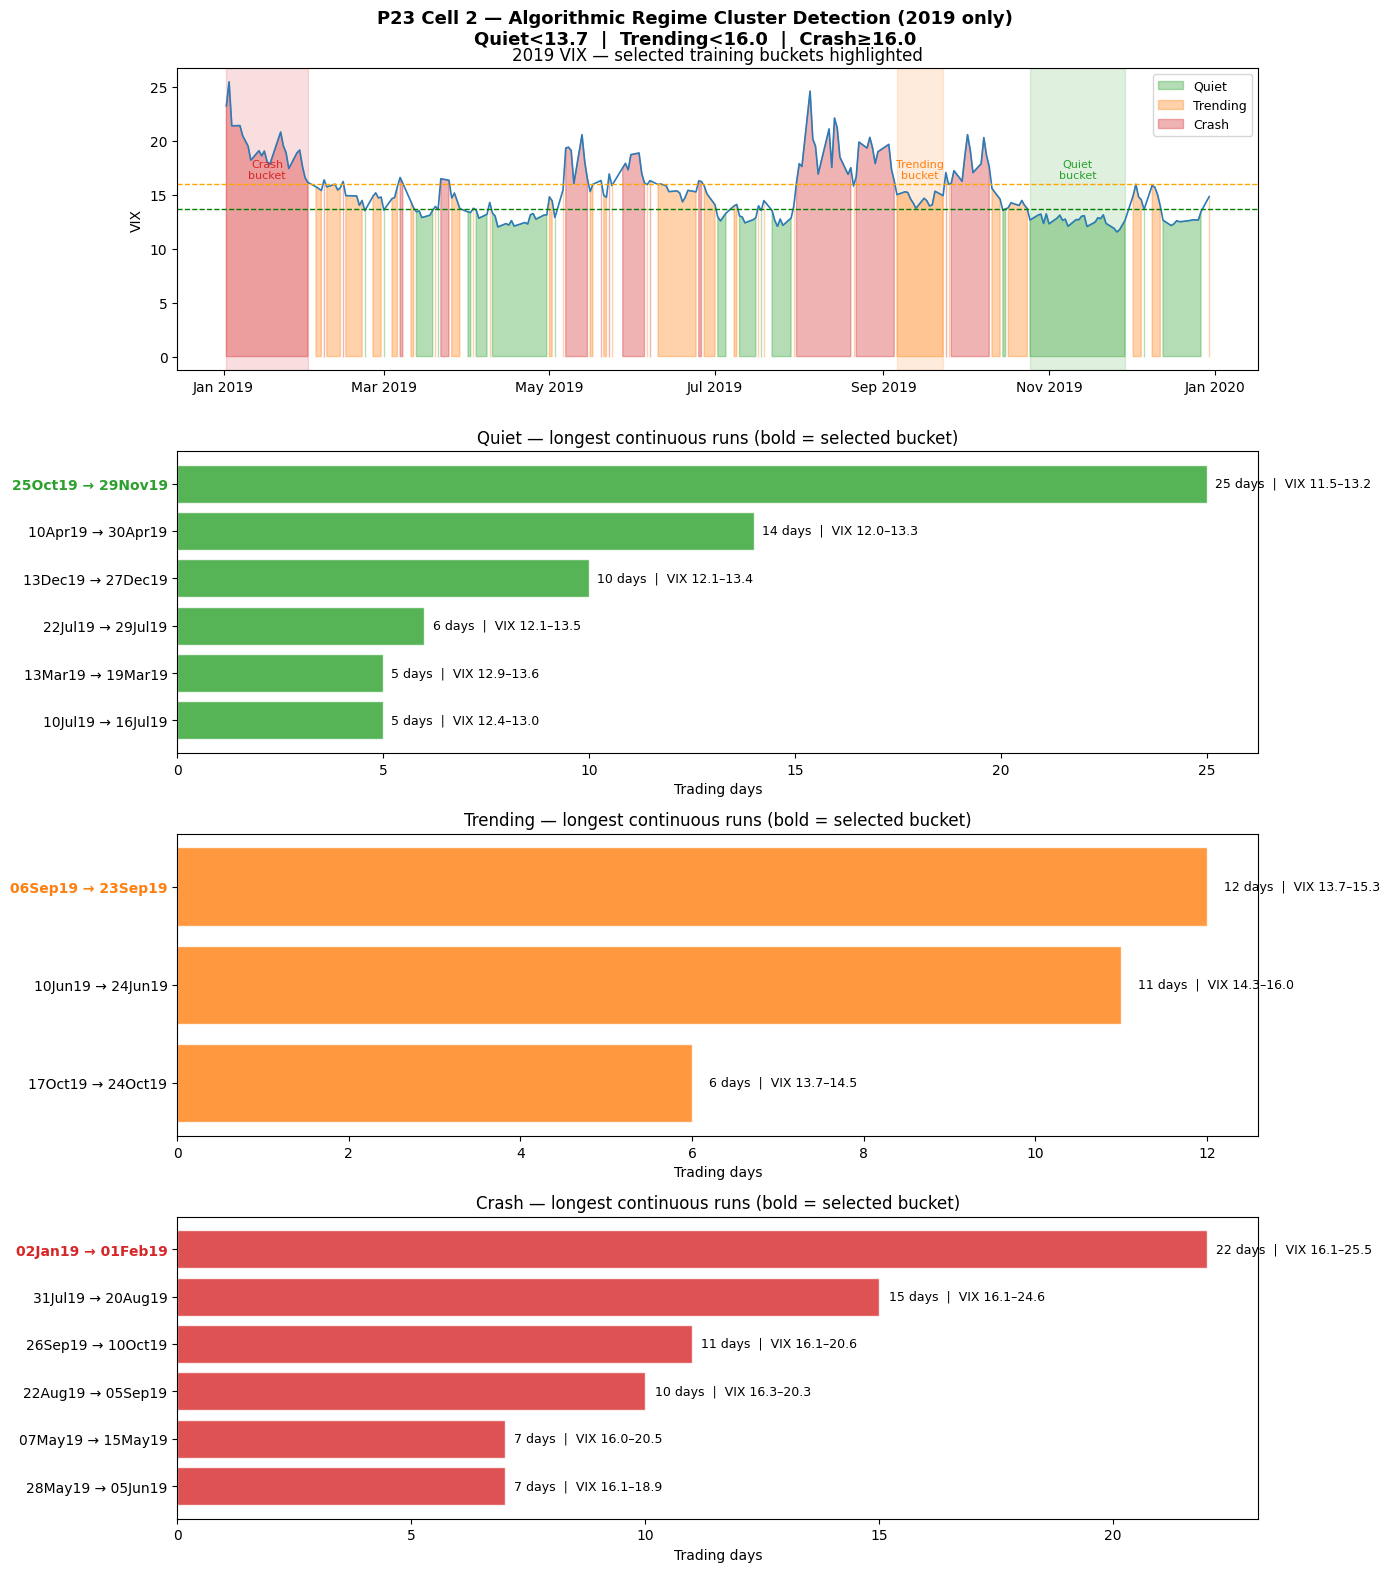


✅ Cell 2 complete. Training buckets locked.
   Do NOT look at 2020 data until Cell 6.


In [6]:
# ============================================================
# PROTOTYPE 23 — Cell 2
# Algorithmic Regime Cluster Detection on 2019 VIX ONLY
# Thresholds: Quiet < 13.7, Trending < 16.0, Crash >= 16.0
# We do not look at 2020. Test window is sealed.
# ============================================================

from pathlib import Path

Q_MAX = 13.7
T_MAX = 16.0

# vix already has "regime" column from Cell 1 with these thresholds
# confirm
print(f"Thresholds confirmed: Quiet<{Q_MAX}, Trending<{T_MAX}, Crash>={T_MAX}")
print(f"VIX window          : {vix.index[0].date()} → {vix.index[-1].date()}")
print(f"Regime counts       : {vix['regime'].value_counts().to_dict()}\n")

def find_continuous_runs(vix_df, regime_name, min_days=5):
    mask  = vix_df["regime"] == regime_name
    runs  = []
    in_run     = False
    start_idx  = None

    for i, (date, is_regime) in enumerate(zip(vix_df.index, mask)):
        if is_regime and not in_run:
            in_run    = True
            start_idx = date
        elif not is_regime and in_run:
            in_run   = False
            end_idx  = vix_df.index[i - 1]
            td       = mask[start_idx:end_idx].sum()
            if td >= min_days:
                runs.append({
                    "start":        start_idx,
                    "end":          end_idx,
                    "trading_days": td,
                    "vix_mean":     vix_df.loc[start_idx:end_idx, "vix"].mean(),
                    "vix_min":      vix_df.loc[start_idx:end_idx, "vix"].min(),
                    "vix_max":      vix_df.loc[start_idx:end_idx, "vix"].max(),
                })
    if in_run:
        end_idx = vix_df.index[-1]
        td      = mask[start_idx:end_idx].sum()
        if td >= min_days:
            runs.append({
                "start":        start_idx,
                "end":          end_idx,
                "trading_days": td,
                "vix_mean":     vix_df.loc[start_idx:end_idx, "vix"].mean(),
                "vix_min":      vix_df.loc[start_idx:end_idx, "vix"].min(),
                "vix_max":      vix_df.loc[start_idx:end_idx, "vix"].max(),
            })

    if not runs:
        return pd.DataFrame(columns=["start","end","trading_days",
                                     "vix_mean","vix_min","vix_max"])
    return (pd.DataFrame(runs)
              .sort_values("trading_days", ascending=False)
              .reset_index(drop=True))

# --- Find runs for all three regimes ---
runs = {}
for regime in ["Quiet", "Trending", "Crash"]:
    runs[regime] = find_continuous_runs(vix, regime, min_days=5)

# --- Print all runs ---
for regime, df in runs.items():
    print(f"\n{'='*58}")
    print(f"  {regime.upper()} — continuous runs ≥ 5 trading days (2019 only)")
    print(f"{'='*58}")
    if len(df) == 0:
        print("  No runs found.")
    else:
        print(df[["start","end","trading_days","vix_mean","vix_min","vix_max"]]
              .head(6).to_string(index=True))

# --- Select best bucket per regime ---
best = {}
for regime in ["Quiet", "Trending", "Crash"]:
    df = runs[regime]
    if len(df) == 0:
        print(f"\n⚠ WARNING: No runs found for {regime}. Cannot proceed.")
    else:
        best[regime] = df.iloc[0]

print("\n" + "="*58)
print("  LOCKED TRAINING BUCKETS FOR STATISTICAL LEARNING")
print("="*58)
for regime, row in best.items():
    print(f"\n  {regime}")
    print(f"    Start        : {row['start'].date()}")
    print(f"    End          : {row['end'].date()}")
    print(f"    Trading days : {row['trading_days']}")
    print(f"    VIX range    : {row['vix_min']:.1f} – {row['vix_max']:.1f}  (mean {row['vix_mean']:.1f})")

# --- Visualise ---
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle(
    "P23 Cell 2 — Algorithmic Regime Cluster Detection (2019 only)\n"
    f"Quiet<{Q_MAX}  |  Trending<{T_MAX}  |  Crash≥{T_MAX}",
    fontsize=13, fontweight='bold'
)

# Panel 1 — full 2019 VIX coloured by regime with bucket highlighted
ax = axes[0]
for regime, col in colors.items():
    mask = vix["regime"] == regime
    ax.fill_between(vix.index, vix["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix.index, vix["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)

# Shade selected training buckets
for regime, row in best.items():
    col = colors[regime]
    ax.axvspan(row["start"], row["end"], alpha=0.15, color=col)
    ax.annotate(
        f"{regime}\nbucket",
        xy=((row["start"] + (row["end"] - row["start"]) / 2), T_MAX + 0.5),
        fontsize=8, color=col, ha="center"
    )

ax.set_ylabel("VIX")
ax.set_title("2019 VIX — selected training buckets highlighted")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Panels 2–4 — horizontal bar charts per regime
for ax, regime in zip(axes[1:], ["Quiet", "Trending", "Crash"]):
    df  = runs[regime].head(6)
    col = colors[regime]

    if len(df) == 0:
        ax.set_title(f"{regime} — no runs found")
        continue

    labels = [
        f"{r['start'].strftime('%d%b%y')} → {r['end'].strftime('%d%b%y')}"
        for _, r in df.iterrows()
    ]
    bars = ax.barh(labels, df["trading_days"],
                   color=col, alpha=0.8, edgecolor="white")

    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{int(row['trading_days'])} days  |  VIX {row['vix_min']:.1f}–{row['vix_max']:.1f}",
            va="center", fontsize=9
        )

    # Bold the winner
    ax.get_yticklabels()[0].set_fontweight('bold')
    ax.get_yticklabels()[0].set_color(col)
    ax.set_title(f"{regime} — longest continuous runs (bold = selected bucket)")
    ax.set_xlabel("Trading days")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell2_regime_clusters.png", dpi=150)
plt.show()

print("\n✅ Cell 2 complete. Training buckets locked.")
print("   Do NOT look at 2020 data until Cell 6.")

In [7]:
import glob
from pathlib import Path

RAW_DIR = Path("./download4")

for regime in ["quiet", "trending", "crash"]:
    files = sorted(glob.glob(str(RAW_DIR / regime / "*.csv")))
    print(f"\n{regime.upper()}:")
    for f in files:
        print(f"  {Path(f).name}")


QUIET:
  spyususd-tick-2019-10-23-2019-11-29.csv

TRENDING:
  spyususd-tick-2019-09-06-2019-09-23.csv

CRASH:
  spyususd-tick-2019-07-31-2019-08-15.csv
  spyususd-tick-2019-08-16-2019-08-20.csv


In [8]:
print(vix.loc["2019-07-31":"2019-08-20", ["vix","regime"]])

                  vix regime
Date                        
2019-07-31  16.120001  Crash
2019-08-01  17.870001  Crash
2019-08-02  17.610001  Crash
2019-08-05  24.590000  Crash
2019-08-06  20.170000  Crash
2019-08-07  19.490000  Crash
2019-08-08  16.910000  Crash
2019-08-09  17.969999  Crash
2019-08-12  21.090000  Crash
2019-08-13  17.520000  Crash
2019-08-14  22.100000  Crash
2019-08-15  21.180000  Crash
2019-08-16  18.469999  Crash
2019-08-19  16.879999  Crash
2019-08-20  17.500000  Crash



  Quiet: 1 file(s) found
    spyususd-tick-2019-10-23-2019-11-29.csv  →  1,729,865 rows
  Total raw rows : 1,729,865

  Trending: 1 file(s) found
    spyususd-tick-2019-09-06-2019-09-23.csv  →  894,285 rows
  Total raw rows : 894,285

  Crash: 2 file(s) found
    spyususd-tick-2019-07-31-2019-08-15.csv  →  1,304,087 rows
    spyususd-tick-2019-08-16-2019-08-20.csv  →  154,593 rows
  Total raw rows : 1,458,680

  CLEANING AUDIT

  Quiet
    after_ts_fix             :  1,729,865
    after_rth                :  1,357,001
    after_gap_remove         :  1,356,974
    after_dt_zero            :  1,356,974
    after_outlier_cap        :  1,355,619
    final_rows               :  1,355,619
    dt_mean (s)              :     0.3685
    dt_median (s)            :     0.1940
    dt_max (s)               :     5.1780

  Trending
    after_ts_fix             :    894,285
    after_rth                :    714,459
    after_gap_remove         :    714,448
    after_dt_zero            :    714,448
 

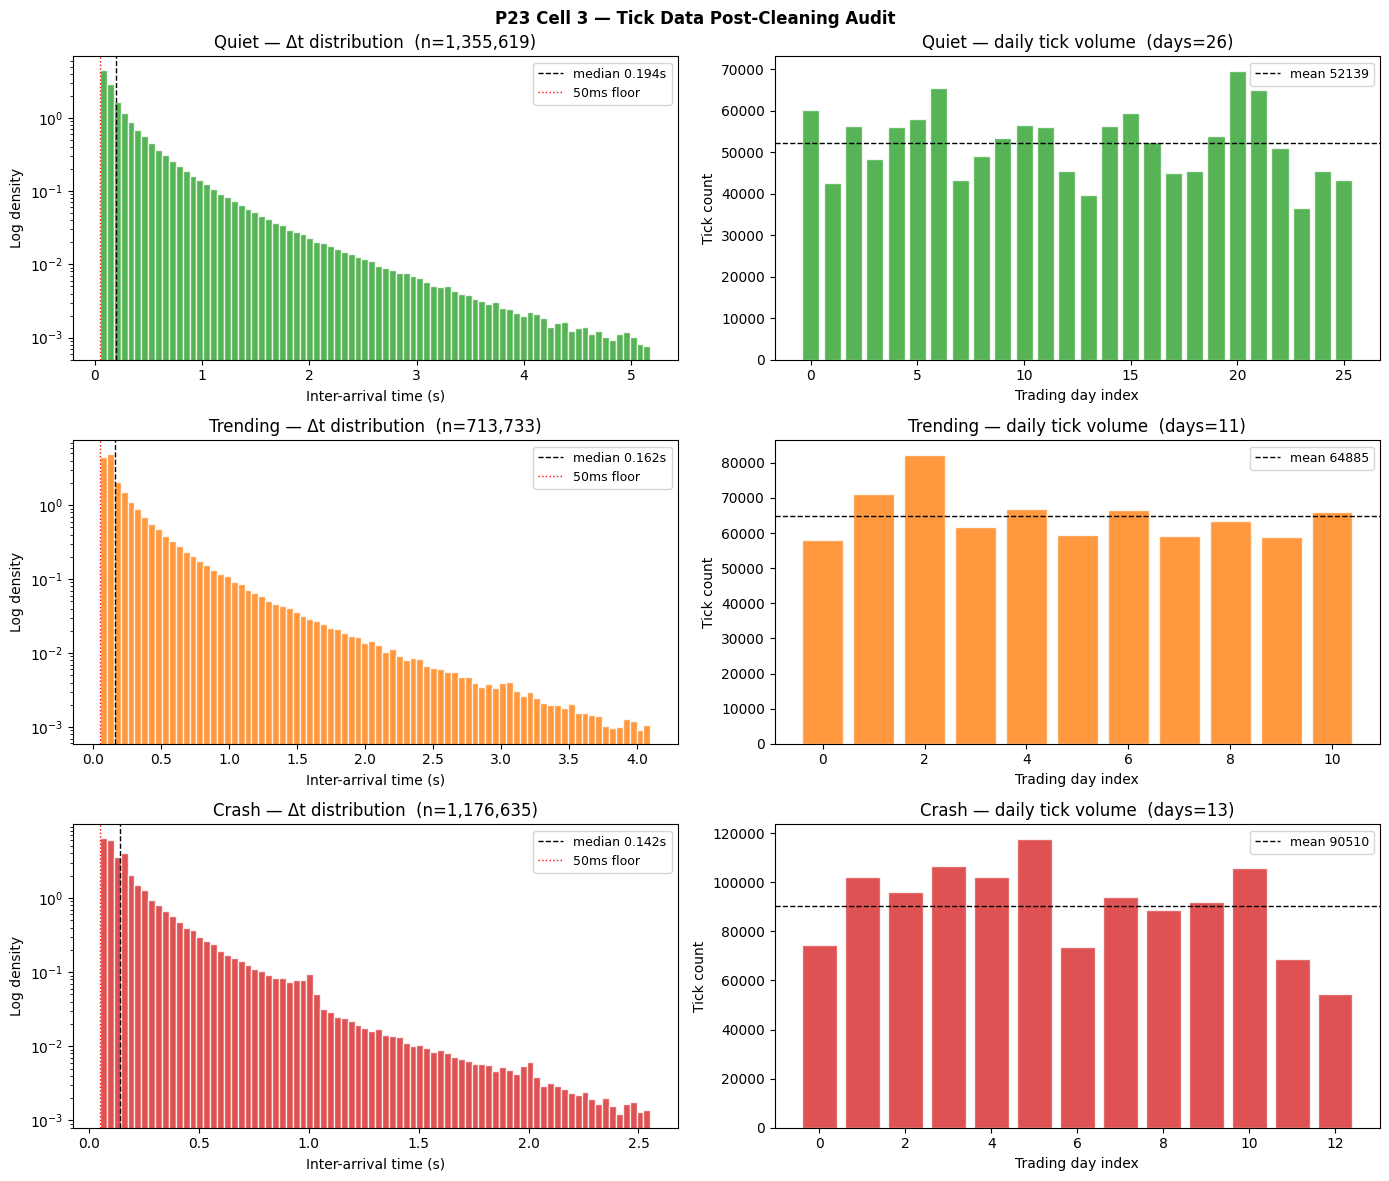


✅ Cell 3 complete.
   Check 50ms floor diagnostic before proceeding to Cell 4.


In [9]:
# ============================================================
# PROTOTYPE 23 — Cell 3
# Load, Clean and Audit Tick Data per Regime
# Same cleaning pipeline as P22, no changes.
# ============================================================

import glob
from pathlib import Path

RAW_DIR = Path("./download4")
OUT_DIR = Path("./p23_output")

REGIME_DIRS = {
    "Quiet":    RAW_DIR / "quiet",
    "Trending": RAW_DIR / "trending",
    "Crash":    RAW_DIR / "crash",
}

def load_regime_ticks(folder, regime_name):
    files = sorted(glob.glob(str(folder / "*.csv")))
    print(f"\n  {regime_name}: {len(files)} file(s) found")
    chunks = []
    for f in files:
        df = pd.read_csv(f, header=0)
        df.columns = [c.strip().lower() for c in df.columns]
        ts_col = [c for c in df.columns if "time" in c or "date" in c][0]
        df = df.rename(columns={ts_col: "ts_raw"})
        chunks.append(df[["ts_raw"]])
        print(f"    {Path(f).name}  →  {len(df):,} rows")
    raw = pd.concat(chunks, ignore_index=True)
    print(f"  Total raw rows : {len(raw):,}")
    return raw

def clean_ticks(raw, regime_name):
    df    = raw.copy()
    stats = {}

    # Fix 1 — millisecond timestamp
    df["ts"] = (pd.to_datetime(df["ts_raw"], unit="ms", utc=True)
                  .dt.tz_convert("US/Eastern")
                  .dt.tz_localize(None))
    stats["after_ts_fix"] = len(df)

    # Fix 2 — RTH filter with 30-min buffer each end
    t = df["ts"].dt.time
    df = df[(t >= pd.to_datetime("10:00").time()) &
            (t <= pd.to_datetime("15:30").time())]
    stats["after_rth"] = len(df)

    # Fix 3 — sort, compute dt, remove overnight gaps
    df = df.sort_values("ts").reset_index(drop=True)
    df["dt"] = df["ts"].diff().dt.total_seconds()
    df = df[df["dt"].notna()]
    df = df[df["dt"] <= 3600]
    stats["after_gap_remove"] = len(df)

    # Fix 4 — remove dt == 0
    df = df[df["dt"] > 0]
    stats["after_dt_zero"] = len(df)

    # Fix 5 — cap outliers at 99.9th percentile
    cap = df["dt"].quantile(0.999)
    df  = df[df["dt"] <= cap]
    stats["after_outlier_cap"] = len(df)

    df = df.reset_index(drop=True)
    return df, stats

# --- Load and clean ---
regime_ticks = {}
regime_stats = {}

for regime, folder in REGIME_DIRS.items():
    raw            = load_regime_ticks(folder, regime)
    cleaned, stats = clean_ticks(raw, regime)
    regime_ticks[regime] = cleaned
    regime_stats[regime] = stats

# --- Audit table ---
print("\n" + "="*60)
print("  CLEANING AUDIT")
print("="*60)
for regime in ["Quiet", "Trending", "Crash"]:
    stats = regime_stats[regime]
    df    = regime_ticks[regime]
    print(f"\n  {regime}")
    for step, count in stats.items():
        print(f"    {step:<25}: {count:>10,}")
    print(f"    {'final_rows':<25}: {len(df):>10,}")
    print(f"    dt_mean (s)              : {df['dt'].mean():>10.4f}")
    print(f"    dt_median (s)            : {df['dt'].median():>10.4f}")
    print(f"    dt_max (s)               : {df['dt'].max():>10.4f}")

# --- 50ms floor diagnostic ---
print("\n" + "="*60)
print("  50ms FLOOR DIAGNOSTIC")
print("="*60)
for regime in ["Quiet", "Trending", "Crash"]:
    df  = regime_ticks[regime]
    pct = (df["dt"] == 0.05).mean() * 100
    pct_near = ((df["dt"] >= 0.049) & (df["dt"] <= 0.051)).mean() * 100
    print(f"  {regime:<10}: exact 0.05s = {pct:.2f}%   near 0.05s = {pct_near:.2f}%")

# --- Visualise ---
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("P23 Cell 3 — Tick Data Post-Cleaning Audit", fontweight='bold')

for row, regime in enumerate(["Quiet", "Trending", "Crash"]):
    df  = regime_ticks[regime]
    col = colors[regime]

    # Left — dt distribution
    ax = axes[row][0]
    ax.hist(df["dt"], bins=80, color=col, alpha=0.8,
            edgecolor="white", density=True)
    ax.set_yscale("log")
    ax.set_xlabel("Inter-arrival time (s)")
    ax.set_ylabel("Log density")
    ax.set_title(f"{regime} — Δt distribution  (n={len(df):,})")
    ax.axvline(df["dt"].median(), color="black", linestyle="--",
               linewidth=1, label=f"median {df['dt'].median():.3f}s")
    ax.axvline(0.05, color="red", linestyle=":",
               linewidth=1, label="50ms floor")
    ax.legend(fontsize=9)

    # Right — daily tick volume
    ax = axes[row][1]
    daily = df.groupby(df["ts"].dt.date).size()
    ax.bar(range(len(daily)), daily.values,
           color=col, alpha=0.8, edgecolor="white")
    ax.set_xlabel("Trading day index")
    ax.set_ylabel("Tick count")
    ax.set_title(f"{regime} — daily tick volume  (days={len(daily)})")
    ax.axhline(daily.mean(), color="black", linestyle="--",
               linewidth=1, label=f"mean {daily.mean():.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell3_tick_audit.png", dpi=150)
plt.show()

print("\n✅ Cell 3 complete.")
print("   Check 50ms floor diagnostic before proceeding to Cell 4.")

In [10]:
# ============================================================
# PROTOTYPE 23 — Cell 4
# Four-way parameter fitting comparison:
#   4A — R-accumulation  + L-BFGS-B
#   4B — R-accumulation  + SLSQP
#   4C — λ+/λ- explicit  + L-BFGS-B
#   4D — λ+/λ- explicit  + SLSQP
# Per-day fitting, 25 restarts, jitter, stationarity penalty
# ============================================================

from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# FORMULATION A/B — R-accumulation (same as P22)
# λ(tk) = µ + α * R[k]   where R[k] = exp(-β*dt[k]) * (1 + R[k-1])
# ------------------------------------------------------------
@njit
def nll_R(mu, alpha, beta, dt):
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return 1e10
    if alpha / beta >= 0.98:
        return 1e10
    n       = len(dt)
    R       = 0.0
    ll      = 0.0
    T       = 0.0
    for i in range(n):
        T   += dt[i]
        R    = np.exp(-beta * dt[i]) * (1.0 + R)
        lam  = mu + alpha * R
        if lam <= 1e-10:
            return 1e10
        ll  += np.log(lam)
    ll -= (mu * T + (alpha / beta) * n)
    return -ll

# ------------------------------------------------------------
# FORMULATION C/D — explicit λ+/λ- recursive update
# λ-(tk) = µ + (λ+(tk-1) - µ) * exp(-β*dt[k])
# λ+(tk) = λ-(tk) + α
# log-likelihood uses λ-(tk)
# ------------------------------------------------------------
@njit
def nll_lam(mu, alpha, beta, dt):
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return 1e10
    if alpha / beta >= 0.98:
        return 1e10
    n        = len(dt)
    lam_plus = mu        # initialise at background rate
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt[i]
        decay     = np.exp(-beta * dt[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return 1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return -ll

# --- Warm up numba ---
print("Compiling numba kernels... ", end="")
_dummy = np.array([0.1, 0.2, 0.15, 0.3])
nll_R(1.0, 0.5, 1.0, _dummy)
nll_lam(1.0, 0.5, 1.0, _dummy)
print("done ✅")

# ------------------------------------------------------------
# Generic per-day fitter
# ------------------------------------------------------------
def fit_single_day(dt_arr, regime, nll_fn, optimizer, n_restarts=25):
    best_nll    = np.inf
    best_params = None
    bounds      = [(1e-4, 50.0), (1e-4, 2.0), (1e-4, 20.0)]

    for _ in range(n_restarts):
        mu0    = np.random.uniform(0.1, 8.0)
        alpha0 = np.random.uniform(0.01, 0.5)
        if regime == "Crash":
            n0 = np.random.uniform(0.3, 0.80)
        elif regime == "Trending":
            n0 = np.random.uniform(0.4, 0.85)
        else:
            n0 = np.random.uniform(0.4, 0.90)
        beta0 = alpha0 / n0
        x0    = [mu0, alpha0, beta0]

        try:
            res = minimize(
                lambda x: nll_fn(x[0], x[1], x[2], dt_arr),
                x0,
                method=optimizer,
                bounds=bounds,
                options={"maxiter": 2000, "ftol": 1e-12,
                         "gtol": 1e-9} if optimizer == "L-BFGS-B"
                        else {"maxiter": 2000, "ftol": 1e-12}
            )
            mu_c, alpha_c, beta_c = res.x
            if alpha_c / beta_c >= 0.98:
                continue
            if res.fun < best_nll:
                best_nll    = res.fun
                best_params = [mu_c, alpha_c, beta_c]
        except Exception:
            continue

    return best_params, best_nll

# ------------------------------------------------------------
# Run all four combinations
# ------------------------------------------------------------
COMBINATIONS = [
    ("4A", "R-accum",  nll_R,   "L-BFGS-B"),
    ("4B", "R-accum",  nll_R,   "SLSQP"),
    ("4C", "λ+/λ-",    nll_lam, "L-BFGS-B"),
    ("4D", "λ+/λ-",    nll_lam, "SLSQP"),
]

all_fits = {}   # keyed by combo label e.g. "4A"

for label, formulation, nll_fn, optimizer in COMBINATIONS:
    print(f"\n{'='*62}")
    print(f"  COMBINATION {label} — {formulation} + {optimizer}")
    print(f"{'='*62}")

    combo_fits = {}

    for regime in ["Quiet", "Trending", "Crash"]:
        df   = regime_ticks[regime]
        days = df["ts"].dt.date.unique()
        print(f"\n  {regime} — {len(days)} days")

        day_results = []
        for day in days:
            day_df = df[df["ts"].dt.date == day]
            dt_arr = day_df["dt"].values.astype(np.float64)

            # Jitter — break 50ms resolution floor
            np.random.seed(int(str(day).replace("-", "")) % 100003)
            dt_arr = dt_arr + np.random.uniform(0.0, 0.049, size=len(dt_arr))

            if len(dt_arr) < 200:
                print(f"    {day}  SKIP  ({len(dt_arr)} ticks)")
                continue

            params, nll = fit_single_day(
                dt_arr, regime=regime,
                nll_fn=nll_fn, optimizer=optimizer, n_restarts=25
            )

            if params is None:
                print(f"    {day}  FAILED")
                continue

            mu, alpha, beta = params
            n_ratio = alpha / beta

            flag = ""
            if n_ratio > 0.90: flag += " ⚠ near-unstable"
            if alpha   < 0.01: flag += " ⚠ alpha-collapse"
            if mu      < 0.05: flag += " ⚠ mu-collapse"

            day_results.append({
                "date": day, "mu": mu, "alpha": alpha,
                "beta": beta, "n_ratio": n_ratio,
                "nll": nll, "n_ticks": len(dt_arr),
            })
            print(f"    {day}  µ={mu:.4f}  α={alpha:.4f}  β={beta:.4f}"
                  f"  n={n_ratio:.3f}  ticks={len(dt_arr):,}{flag}")

        combo_fits[regime] = pd.DataFrame(day_results)

    all_fits[label] = combo_fits

print("\n✅ All four combinations complete.")

Compiling numba kernels... done ✅

  COMBINATION 4A — R-accum + L-BFGS-B

  Quiet — 26 days
    2019-10-23  µ=0.5028  α=0.0803  β=0.0975  n=0.823  ticks=60,324
    2019-10-24  µ=0.3260  α=0.0972  β=0.1096  n=0.887  ticks=42,660
    2019-10-25  µ=0.4820  α=0.0998  β=0.1216  n=0.821  ticks=56,476
    2019-10-28  µ=0.6234  α=0.1147  β=0.1562  n=0.734  ticks=48,487
    2019-10-29  µ=0.4751  α=0.0908  β=0.1104  n=0.822  ticks=56,147
    2019-10-30  µ=0.3608  α=0.1082  β=0.1242  n=0.871  ticks=57,994
    2019-10-31  µ=0.5686  α=0.0976  β=0.1193  n=0.818  ticks=65,485
    2019-11-01  µ=0.4667  α=0.1212  β=0.1551  n=0.782  ticks=43,419
    2019-11-04  µ=0.6330  α=0.1122  β=0.1530  n=0.734  ticks=49,071
    2019-11-05  µ=0.4104  α=0.0939  β=0.1116  n=0.841  ticks=53,563
    2019-11-06  µ=0.4350  α=0.0993  β=0.1184  n=0.839  ticks=56,613
    2019-11-07  µ=0.5183  α=0.1128  β=0.1399  n=0.806  ticks=56,061
    2019-11-08  µ=0.3031  α=0.1009  β=0.1166  n=0.866  ticks=45,582
    2019-11-11  µ=0.4496

  FROZEN PARAMETERS PER COMBINATION

  4A — R-accum + L-BFGS-B
  Regime            µ        α        β        n   days_used   excl
  Quiet        0.4582   0.1004   0.1204   0.8334          26      0
  Trending     0.4392   0.0750   0.0826   0.9072          11      0
  Crash        1.1447   0.0423   0.0567   0.7460          12      1

  4B — R-accum + SLSQP
  Regime            µ        α        β        n   days_used   excl
  Quiet        0.4582   0.1004   0.1204   0.8334          26      0
  Trending     0.4392   0.0750   0.0826   0.9072          11      0
  Crash        1.1447   0.0423   0.0567   0.7460          12      1

  4C — λ+/λ- + L-BFGS-B
  Regime            µ        α        β        n   days_used   excl
  Quiet        0.4606   0.1005   0.1207   0.8328          26      0
  Trending     0.4428   0.0750   0.0828   0.9062          11      0
  Crash        1.1278   0.0423   0.0542   0.7798          13      0

  4D — λ+/λ- + SLSQP
  Regime            µ        α        β        n  

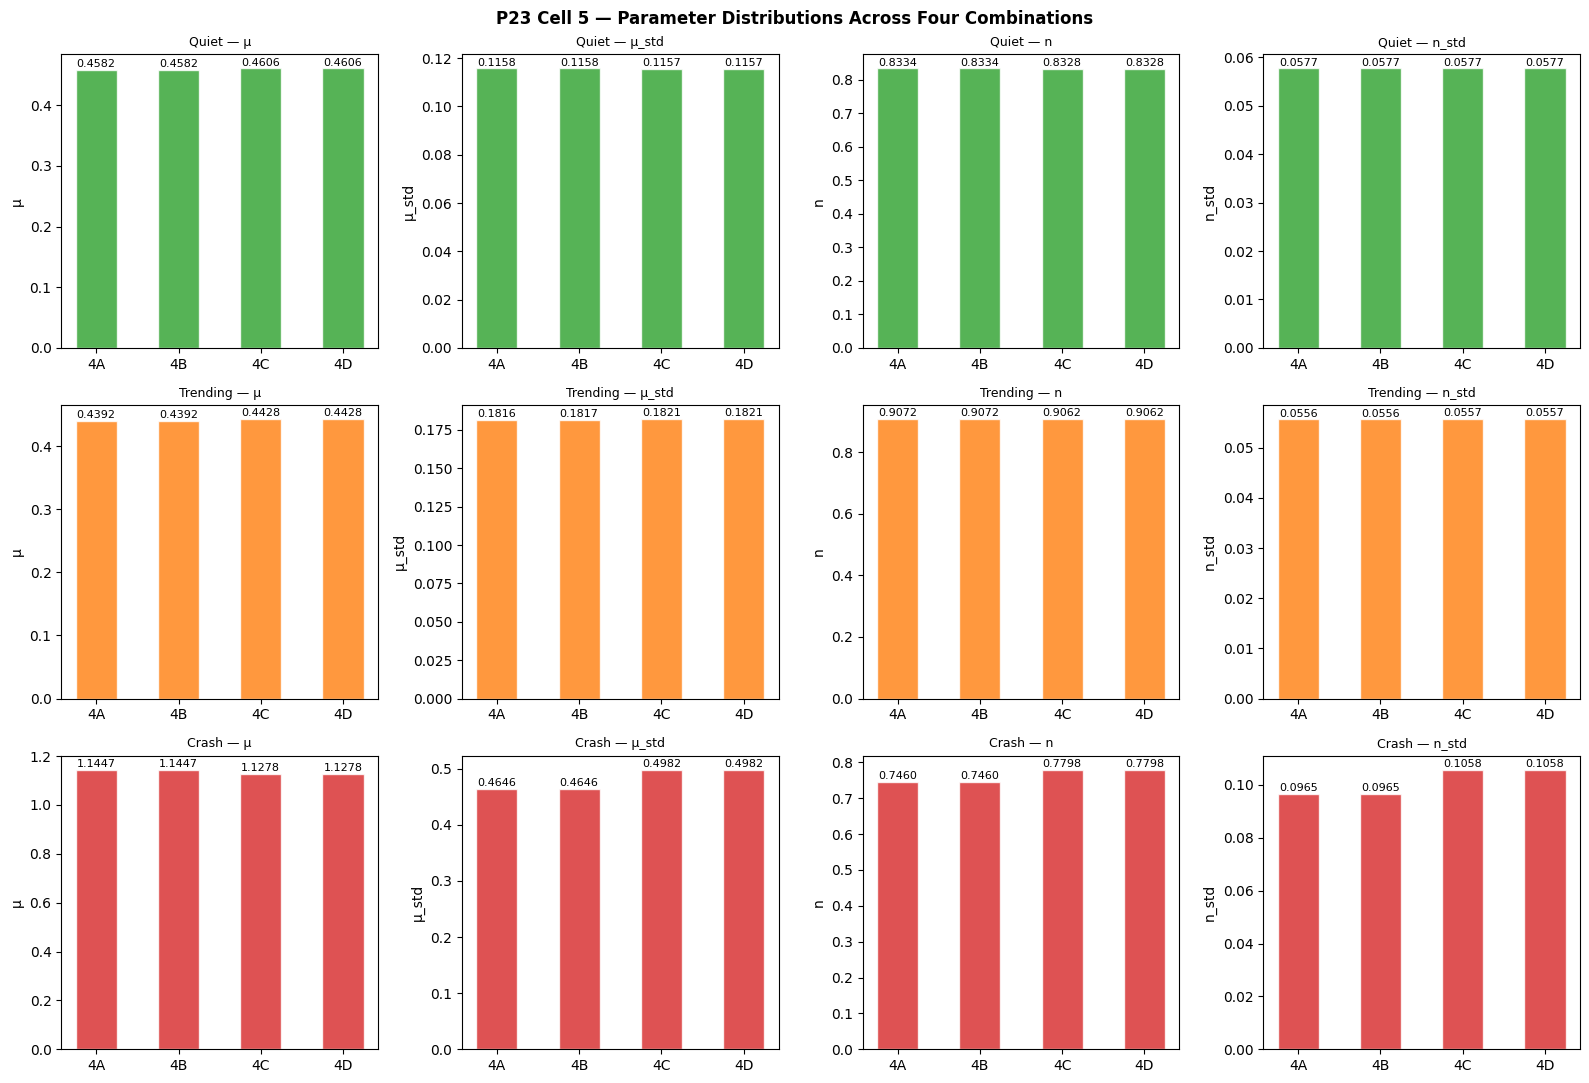


✅ Cell 5 complete. Frozen parameters locked. Ready for Cell 6.


In [11]:
# ============================================================
# PROTOTYPE 23 — Cell 5
# Frozen Parameter Extraction + Four-Way Comparison Table
# ============================================================

import pandas as pd
import numpy as np

# --- Exclusion criteria ---
N_UNSTABLE_THRESH  = 0.95   # exclude near-unstable days
ALPHA_COLLAPSE_MIN = 0.01   # exclude alpha-collapse days

def extract_frozen(combo_fits, label):
    frozen = {}
    summary = {}
    for regime in ["Quiet", "Trending", "Crash"]:
        df     = combo_fits[regime].copy()
        before = len(df)
        df     = df[(df["n_ratio"] < N_UNSTABLE_THRESH) &
                    (df["alpha"]   >= ALPHA_COLLAPSE_MIN)]
        after  = len(df)
        excluded = before - after

        mu    = df["mu"].median()
        alpha = df["alpha"].median()
        beta  = df["beta"].median()
        n     = alpha / beta

        frozen[regime] = {"mu": mu, "alpha": alpha, "beta": beta, "n": n}
        summary[regime] = {
            "days_total":    before,
            "days_excluded": excluded,
            "days_used":     after,
            "mu_median":     mu,
            "mu_std":        df["mu"].std(),
            "alpha_median":  alpha,
            "alpha_std":     df["alpha"].std(),
            "beta_median":   beta,
            "beta_std":      df["beta"].std(),
            "n_median":      n,
            "n_std":         df["n_ratio"].std(),
        }
    return frozen, summary

# --- Extract for all four combinations ---
frozen_all  = {}
summary_all = {}

for label, _, _, _ in COMBINATIONS:
    frozen_all[label], summary_all[label] = extract_frozen(all_fits[label], label)

# --- Print per-combo frozen params ---
print("=" * 65)
print("  FROZEN PARAMETERS PER COMBINATION")
print("=" * 65)
for label, formulation, _, optimizer in COMBINATIONS:
    print(f"\n  {label} — {formulation} + {optimizer}")
    print(f"  {'Regime':<10} {'µ':>8} {'α':>8} {'β':>8} {'n':>8}  "
          f"{'days_used':>10} {'excl':>6}")
    for regime in ["Quiet", "Trending", "Crash"]:
        p = frozen_all[label][regime]
        s = summary_all[label][regime]
        print(f"  {regime:<10} {p['mu']:>8.4f} {p['alpha']:>8.4f} "
              f"{p['beta']:>8.4f} {p['n']:>8.4f}  "
              f"{s['days_used']:>10} {s['days_excluded']:>6}")

# --- Four-way comparison table ---
print("\n\n" + "=" * 75)
print("  FOUR-WAY COMPARISON TABLE")
print("=" * 75)

rows = []
for label, formulation, _, optimizer in COMBINATIONS:
    for regime in ["Quiet", "Trending", "Crash"]:
        s = summary_all[label][regime]
        p = frozen_all[label][regime]
        rows.append({
            "Combo":      label,
            "Formulation":formulation,
            "Optimizer":  optimizer,
            "Regime":     regime,
            "µ":          round(p["mu"],    4),
            "µ_std":      round(s["mu_std"],4),
            "α":          round(p["alpha"], 4),
            "β":          round(p["beta"],  4),
            "n":          round(p["n"],     4),
            "n_std":      round(s["n_std"], 4),
            "days_used":  s["days_used"],
            "excluded":   s["days_excluded"],
        })

comp_df = pd.DataFrame(rows)

for regime in ["Quiet", "Trending", "Crash"]:
    print(f"\n  {regime.upper()}")
    sub = comp_df[comp_df["Regime"] == regime][
        ["Combo","Formulation","Optimizer","µ","µ_std","α","β","n","n_std",
         "days_used","excluded"]
    ]
    print(sub.to_string(index=False))

# --- Winner selection ---
print("\n\n" + "=" * 65)
print("  WINNER SELECTION")
print("=" * 65)
print("\n  Criteria: lowest total excluded days + lowest n_std across regimes")

winner_scores = {}
for label, formulation, _, optimizer in COMBINATIONS:
    total_excluded = sum(
        summary_all[label][r]["days_excluded"]
        for r in ["Quiet","Trending","Crash"]
    )
    mean_n_std = np.mean([
        summary_all[label][r]["n_std"]
        for r in ["Quiet","Trending","Crash"]
    ])
    winner_scores[label] = {
        "formulation":   formulation,
        "optimizer":     optimizer,
        "total_excluded":total_excluded,
        "mean_n_std":    round(mean_n_std, 5),
    }
    print(f"\n  {label} — {formulation} + {optimizer}")
    print(f"    Total excluded days : {total_excluded}")
    print(f"    Mean n std          : {mean_n_std:.5f}")

best_label = min(winner_scores,
                 key=lambda x: (winner_scores[x]["total_excluded"],
                                winner_scores[x]["mean_n_std"]))
print(f"\n  >>> WINNER: {best_label} — "
      f"{winner_scores[best_label]['formulation']} + "
      f"{winner_scores[best_label]['optimizer']}")

# --- Lock winning frozen params ---
frozen = frozen_all[best_label]

print(f"\n\n" + "=" * 65)
print(f"  LOCKED FROZEN PARAMETERS (from {best_label})")
print("=" * 65)
for regime in ["Quiet", "Trending", "Crash"]:
    p = frozen[regime]
    print(f"\n  {regime}")
    print(f"    mu    = {p['mu']:.6f}")
    print(f"    alpha = {p['alpha']:.6f}")
    print(f"    beta  = {p['beta']:.6f}")
    print(f"    n     = {p['n']:.6f}")

# --- Visualise parameter distributions across combos ---
colors_regime = {"Quiet":"#2ca02c","Trending":"#ff7f0e","Crash":"#d62728"}
combo_labels  = [l for l, *_ in COMBINATIONS]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("P23 Cell 5 — Parameter Distributions Across Four Combinations",
             fontweight='bold')

params_plot  = ["µ", "µ_std", "n", "n_std"]
for row, regime in enumerate(["Quiet","Trending","Crash"]):
    col_c = colors_regime[regime]
    sub   = comp_df[comp_df["Regime"] == regime]
    for ci, param in enumerate(params_plot):
        ax = axes[row][ci]
        bars = ax.bar(sub["Combo"], sub[param],
                      color=col_c, alpha=0.8, edgecolor="white", width=0.5)
        for bar, val in zip(bars, sub[param]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + sub[param].max()*0.01,
                    f"{val:.4f}", ha="center", fontsize=8)
        ax.set_title(f"{regime} — {param}", fontsize=9)
        ax.set_ylabel(param)

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell5_comparison.png", dpi=150)
plt.show()

print("\n✅ Cell 5 complete. Frozen parameters locked. Ready for Cell 6.")

In [12]:
import glob
from pathlib import Path

TEST_DIR = Path("./download4/test")
files = sorted(glob.glob(str(TEST_DIR / "*.csv")))
for f in files:
    print(Path(f).name)

spyususd-tick-2020-01-01-2020-01-31.csv
spyususd-tick-2020-02-01-2020-02-10.csv
spyususd-tick-2020-02-11-2020-02-20.csv
spyususd-tick-2020-02-21-2020-02-29.csv
spyususd-tick-2020-03-01-2020-03-05.csv
spyususd-tick-2020-03-06-2020-03-10.csv
spyususd-tick-2020-03-11-2020-03-15.csv
spyususd-tick-2020-03-16-2020-03-20.csv
spyususd-tick-2020-03-21-2020-03-25.csv
spyususd-tick-2020-03-26-2020-03-31.csv
spyususd-tick-2020-04-01-2020-04-10.csv
spyususd-tick-2020-04-11-2020-04-20.csv
spyususd-tick-2020-04-21-2020-04-30.csv


Frozen parameters locked (4C — λ+/λ- + L-BFGS-B):
  Quiet   : µ=0.460554  α=0.100498  β=0.120670  n=0.8328
  Trending: µ=0.442767  α=0.074992  β=0.082754  n=0.9062
  Crash   : µ=1.127802  α=0.042262  β=0.054195  n=0.7798

Compiling numba kernel... done ✅

Loading test tick data...
  spyususd-tick-2020-01-01-2020-01-31.csv  →  1,910,382 rows
  spyususd-tick-2020-02-01-2020-02-10.csv  →  535,903 rows
  spyususd-tick-2020-02-11-2020-02-20.csv  →  553,609 rows
  spyususd-tick-2020-02-21-2020-02-29.csv  →  1,197,557 rows
  spyususd-tick-2020-03-01-2020-03-05.csv  →  681,322 rows
  spyususd-tick-2020-03-06-2020-03-10.csv  →  467,468 rows
  spyususd-tick-2020-03-11-2020-03-15.csv  →  724,916 rows
  spyususd-tick-2020-03-16-2020-03-20.csv  →  918,215 rows
  spyususd-tick-2020-03-21-2020-03-25.csv  →  513,150 rows
  spyususd-tick-2020-03-26-2020-03-31.csv  →  691,450 rows
  spyususd-tick-2020-04-01-2020-04-10.csv  →  1,406,597 rows
  spyususd-tick-2020-04-11-2020-04-20.csv  →  881,977 rows
  sp

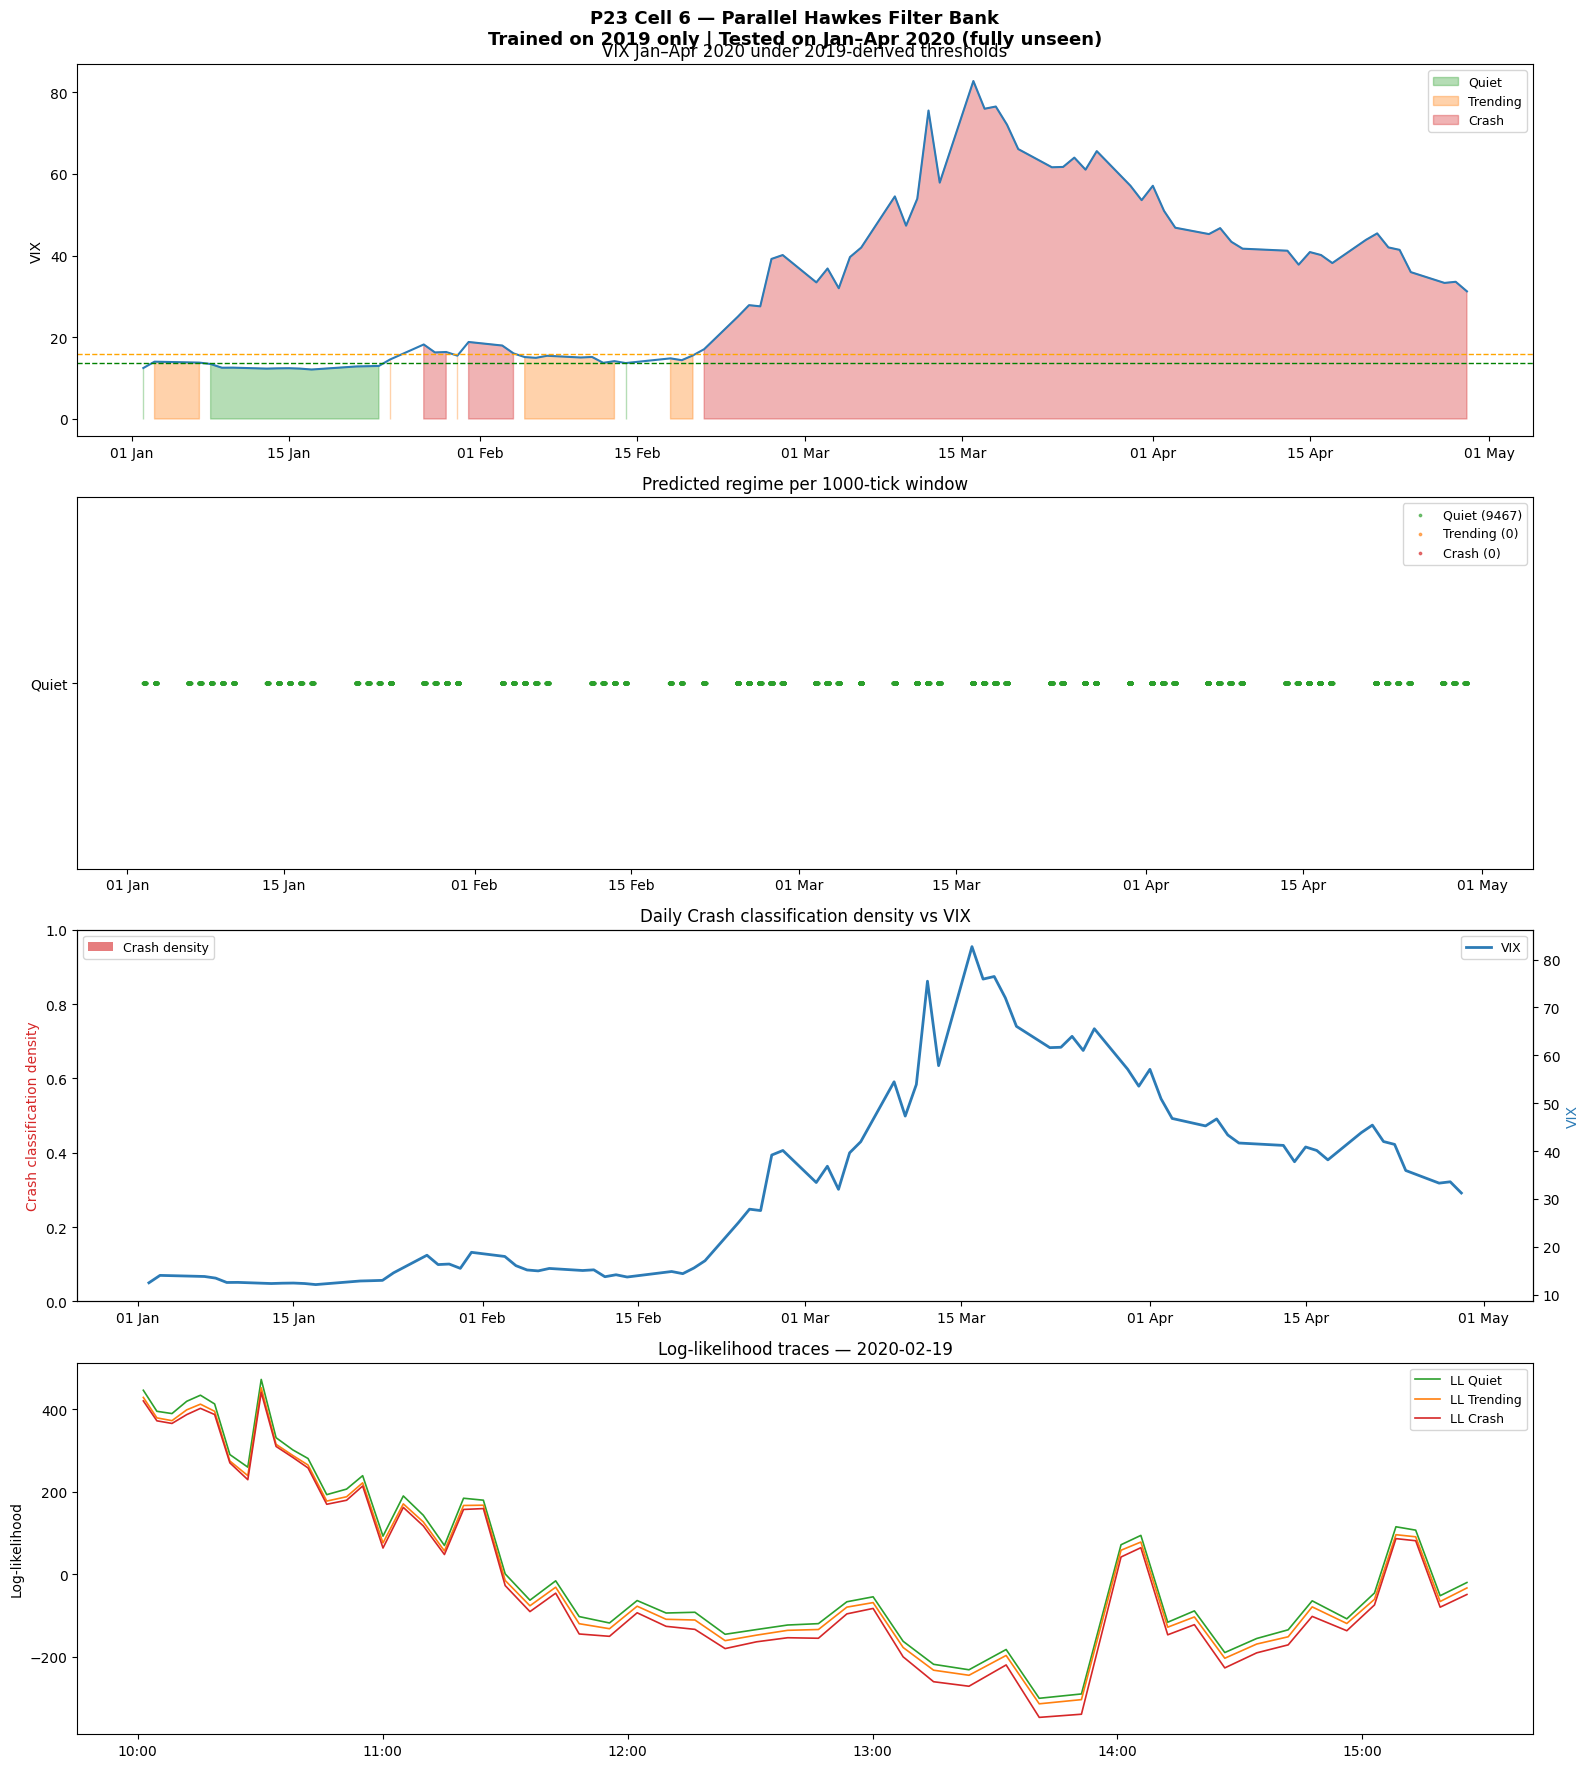


✅ Cell 6 complete.


In [13]:
# ============================================================
# PROTOTYPE 23 — Cell 6
# Parallel Hawkes Filter Bank on Jan–Apr 2020
# Trained on 2019 only. Test window is fully unseen.
# ============================================================

from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
from pathlib import Path

TEST_DIR = Path("./download4/test")

# --- Frozen parameters from Cell 5 winner (4C) ---
MU_Q,  ALPHA_Q,  BETA_Q  = 0.460554, 0.100498, 0.120670
MU_T,  ALPHA_T,  BETA_T  = 0.442767, 0.074992, 0.082754
MU_C,  ALPHA_C,  BETA_C  = 1.127802, 0.042262, 0.054195

print("Frozen parameters locked (4C — λ+/λ- + L-BFGS-B):")
print(f"  Quiet   : µ={MU_Q:.6f}  α={ALPHA_Q:.6f}  β={BETA_Q:.6f}  n={ALPHA_Q/BETA_Q:.4f}")
print(f"  Trending: µ={MU_T:.6f}  α={ALPHA_T:.6f}  β={BETA_T:.6f}  n={ALPHA_T/BETA_T:.4f}")
print(f"  Crash   : µ={MU_C:.6f}  α={ALPHA_C:.6f}  β={BETA_C:.6f}  n={ALPHA_C/BETA_C:.4f}")

# --- LL window function (λ+/λ- formulation, matching winner) ---
@njit
def hawkes_ll_window(mu, alpha, beta, dt_window):
    n        = len(dt_window)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt_window[i]
        decay     = np.exp(-beta * dt_window[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return -1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return ll

# Warm up
print("\nCompiling numba kernel... ", end="")
hawkes_ll_window(1.0, 0.1, 0.2, np.array([0.1, 0.2, 0.3]))
print("done ✅")

# --- Load and clean test ticks ---
print("\nLoading test tick data...")
chunks = []
for f in sorted(glob.glob(str(TEST_DIR / "*.csv"))):
    df = pd.read_csv(f, header=0)
    df.columns = [c.strip().lower() for c in df.columns]
    ts_col = [c for c in df.columns if "time" in c or "date" in c][0]
    df = df.rename(columns={ts_col: "ts_raw"})
    chunks.append(df[["ts_raw"]])
    print(f"  {Path(f).name}  →  {len(df):,} rows")

raw_test = pd.concat(chunks, ignore_index=True)
print(f"\nTotal raw rows: {len(raw_test):,}")

# Clean — identical pipeline to Cell 3
raw_test["ts"] = (pd.to_datetime(raw_test["ts_raw"], unit="ms", utc=True)
                    .dt.tz_convert("US/Eastern")
                    .dt.tz_localize(None))
t = raw_test["ts"].dt.time
raw_test = raw_test[
    (t >= pd.to_datetime("10:00").time()) &
    (t <= pd.to_datetime("15:30").time())
]
raw_test = raw_test.sort_values("ts").reset_index(drop=True)
raw_test["dt"] = raw_test["ts"].diff().dt.total_seconds()
raw_test = raw_test[raw_test["dt"].notna()]
raw_test = raw_test[raw_test["dt"] <= 3600]
raw_test = raw_test[raw_test["dt"] > 0]
cap = raw_test["dt"].quantile(0.999)
raw_test = raw_test[raw_test["dt"] <= cap].reset_index(drop=True)

print(f"After cleaning : {len(raw_test):,} ticks")
print(f"Date range     : {raw_test['ts'].min().date()} → {raw_test['ts'].max().date()}")
print(f"dt mean        : {raw_test['dt'].mean():.4f}s")

# --- Attach VIX labels ---
# Download VIX for Jan–Apr 2020
vix_test = yf.download("^VIX", start="2020-01-01", end="2020-04-30",
                        auto_adjust=True, progress=False)[["Close"]].copy()
vix_test.columns = ["vix"]
vix_test.index = pd.to_datetime(vix_test.index)
if vix_test.index.tz is not None:
    vix_test.index = vix_test.index.tz_localize(None)

# Apply 2019-derived thresholds — no peeking
vix_test["regime"] = np.where(vix_test["vix"] < Q_MAX,  "Quiet",
                     np.where(vix_test["vix"] < T_MAX, "Trending", "Crash"))

raw_test["date"] = pd.to_datetime(raw_test["ts"].dt.date)
raw_test = raw_test.merge(vix_test[["regime"]], left_on="date",
                          right_index=True, how="left")
raw_test["regime"] = raw_test["regime"].ffill()

print(f"\nTick count per VIX regime (test window):")
print(raw_test["regime"].value_counts().to_string())

# --- Apply jitter ---
np.random.seed(20200101 % 100003)
dt_all     = raw_test["dt"].values.astype(np.float64)
dt_all     = dt_all + np.random.uniform(0.0, 0.049, size=len(dt_all))
ts_all     = raw_test["ts"].values
regime_all = raw_test["regime"].values

# --- Run filter bank ---
WINDOW_SIZE = 1000
n_windows   = len(dt_all) // WINDOW_SIZE

print(f"\nRunning filter bank...")
print(f"  Total ticks  : {len(dt_all):,}")
print(f"  Window size  : {WINDOW_SIZE}")
print(f"  Total windows: {n_windows:,}")

results = []
for w in range(n_windows):
    start = w * WINDOW_SIZE
    end   = start + WINDOW_SIZE

    dt_win  = dt_all[start:end]
    ts_mid  = ts_all[start + WINDOW_SIZE // 2]

    # True regime — majority vote
    unique, counts = np.unique(regime_all[start:end], return_counts=True)
    true_regime    = unique[np.argmax(counts)]

    # Parallel MLE
    ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_win)
    ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_win)
    ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_win)

    pred = ["Quiet", "Trending", "Crash"][np.argmax([ll_q, ll_t, ll_c])]

    results.append({
        "ts":          pd.Timestamp(ts_mid),
        "true_regime": true_regime,
        "pred_regime": pred,
        "ll_quiet":    ll_q,
        "ll_trending": ll_t,
        "ll_crash":    ll_c,
        "correct":     pred == true_regime,
    })

results_df = pd.DataFrame(results)
results_df["ts"] = pd.to_datetime(results_df["ts"])

# --- Classification accuracy ---
print(f"\n{'='*55}")
print(f"  CLASSIFICATION RESULTS")
print(f"{'='*55}")
overall = results_df["correct"].mean()
print(f"\n  Overall accuracy : {overall:.1%}")
print(f"\n  Per-regime accuracy:")
for regime in ["Quiet", "Trending", "Crash"]:
    sub = results_df[results_df["true_regime"] == regime]
    if len(sub) == 0:
        continue
    acc = sub["correct"].mean()
    print(f"    {regime:<10}: {acc:.1%}  ({len(sub):,} windows)")

# --- Confusion matrix ---
from sklearn.metrics import confusion_matrix
labels = ["Quiet", "Trending", "Crash"]
cm = confusion_matrix(results_df["true_regime"],
                      results_df["pred_regime"], labels=labels)
print(f"\n  Confusion matrix (rows=true, cols=pred):")
print(f"  {'':10} {'Quiet':>8} {'Trending':>10} {'Crash':>8}")
for i, label in enumerate(labels):
    print(f"  {label:<10} {cm[i,0]:>8} {cm[i,1]:>10} {cm[i,2]:>8}")

# --- Visualise ---
colors = {"Quiet":"#2ca02c", "Trending":"#ff7f0e", "Crash":"#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle(
    "P23 Cell 6 — Parallel Hawkes Filter Bank\n"
    "Trained on 2019 only | Tested on Jan–Apr 2020 (fully unseen)",
    fontsize=13, fontweight='bold'
)

# Panel 1 — VIX with regime labels
ax = axes[0]
for regime, col in colors.items():
    mask = vix_test["regime"] == regime
    ax.fill_between(vix_test.index, vix_test["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix_test.index, vix_test["vix"], color="#2c7bb6", linewidth=1.5)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.set_ylabel("VIX")
ax.set_title("VIX Jan–Apr 2020 under 2019-derived thresholds")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 2 — predicted regime scatter
ax = axes[1]
for regime, col in colors.items():
    mask = results_df["pred_regime"] == regime
    ax.scatter(results_df.loc[mask, "ts"], [regime]*mask.sum(),
               color=col, s=3, alpha=0.6, label=f"{regime} ({mask.sum()})")
ax.set_title("Predicted regime per 1000-tick window")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 3 — crash density vs VIX
ax  = axes[2]
ax2 = ax.twinx()

results_df["ts_floor"] = results_df["ts"].dt.floor("1D")
crash_density = (results_df.groupby("ts_floor")
                 .apply(lambda x: (x["pred_regime"] == "Crash").mean())
                 .reset_index(name="crash_density"))

ax.bar(crash_density["ts_floor"], crash_density["crash_density"],
       width=pd.Timedelta("1D"), color="#d62728", alpha=0.6,
       label="Crash density")
ax.set_ylabel("Crash classification density", color="#d62728")
ax.set_ylim(0, 1)
ax2.plot(vix_test.index, vix_test["vix"], color="#2c7bb6",
         linewidth=2, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Daily Crash classification density vs VIX")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 4 — LL traces for a sample day
ax = axes[3]
# Pick first day that has all three regimes represented in predictions
sample_date = results_df["ts"].dt.date.unique()[30]  # ~Feb 2020
sample = results_df[results_df["ts"].dt.date == sample_date]
ax.plot(sample["ts"], sample["ll_quiet"],    color="#2ca02c",
        label="LL Quiet",    linewidth=1.2)
ax.plot(sample["ts"], sample["ll_trending"], color="#ff7f0e",
        label="LL Trending", linewidth=1.2)
ax.plot(sample["ts"], sample["ll_crash"],    color="#d62728",
        label="LL Crash",    linewidth=1.2)
ax.set_title(f"Log-likelihood traces — {sample_date}")
ax.set_ylabel("Log-likelihood")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell6_filterbank.png", dpi=150)
plt.show()

print("\n✅ Cell 6 complete.")

In [14]:
# Diagnostic — µ scale mismatch quantification
print("TRAINING tick rates (1/dt_mean):")
for regime in ["Quiet", "Trending", "Crash"]:
    dm = regime_ticks[regime]["dt"].mean()
    print(f"  {regime:<10}: dt_mean={dm:.4f}s  rate={1/dm:.2f} events/s")

print(f"\nTEST window tick rate:")
print(f"  Overall    : dt_mean={raw_test['dt'].mean():.4f}s  "
      f"rate={1/raw_test['dt'].mean():.2f} events/s")

print(f"\nFrozen µ values vs implied rate:")
for regime, mu in [("Quiet", MU_Q), ("Trending", MU_T), ("Crash", MU_C)]:
    print(f"  {regime:<10}: µ={mu:.4f}  implied_rate={mu:.2f} events/s")

print(f"\nMismatch ratio (actual_test_rate / crash_mu):")
actual = 1/raw_test["dt"].mean()
print(f"  {actual:.2f} / {MU_C:.4f} = {actual/MU_C:.2f}×")

TRAINING tick rates (1/dt_mean):
  Quiet     : dt_mean=0.3685s  rate=2.71 events/s
  Trending  : dt_mean=0.2997s  rate=3.34 events/s
  Crash     : dt_mean=0.2151s  rate=4.65 events/s

TEST window tick rate:
  Overall    : dt_mean=0.1486s  rate=6.73 events/s

Frozen µ values vs implied rate:
  Quiet     : µ=0.4606  implied_rate=0.46 events/s
  Trending  : µ=0.4428  implied_rate=0.44 events/s
  Crash     : µ=1.1278  implied_rate=1.13 events/s

Mismatch ratio (actual_test_rate / crash_mu):
  6.73 / 1.1278 = 5.97×



Crash density aggregation...

Daily crash density stats:
  mean  : 0.000
  max   : 0.000
  days with crash_density > 0.5 : 0


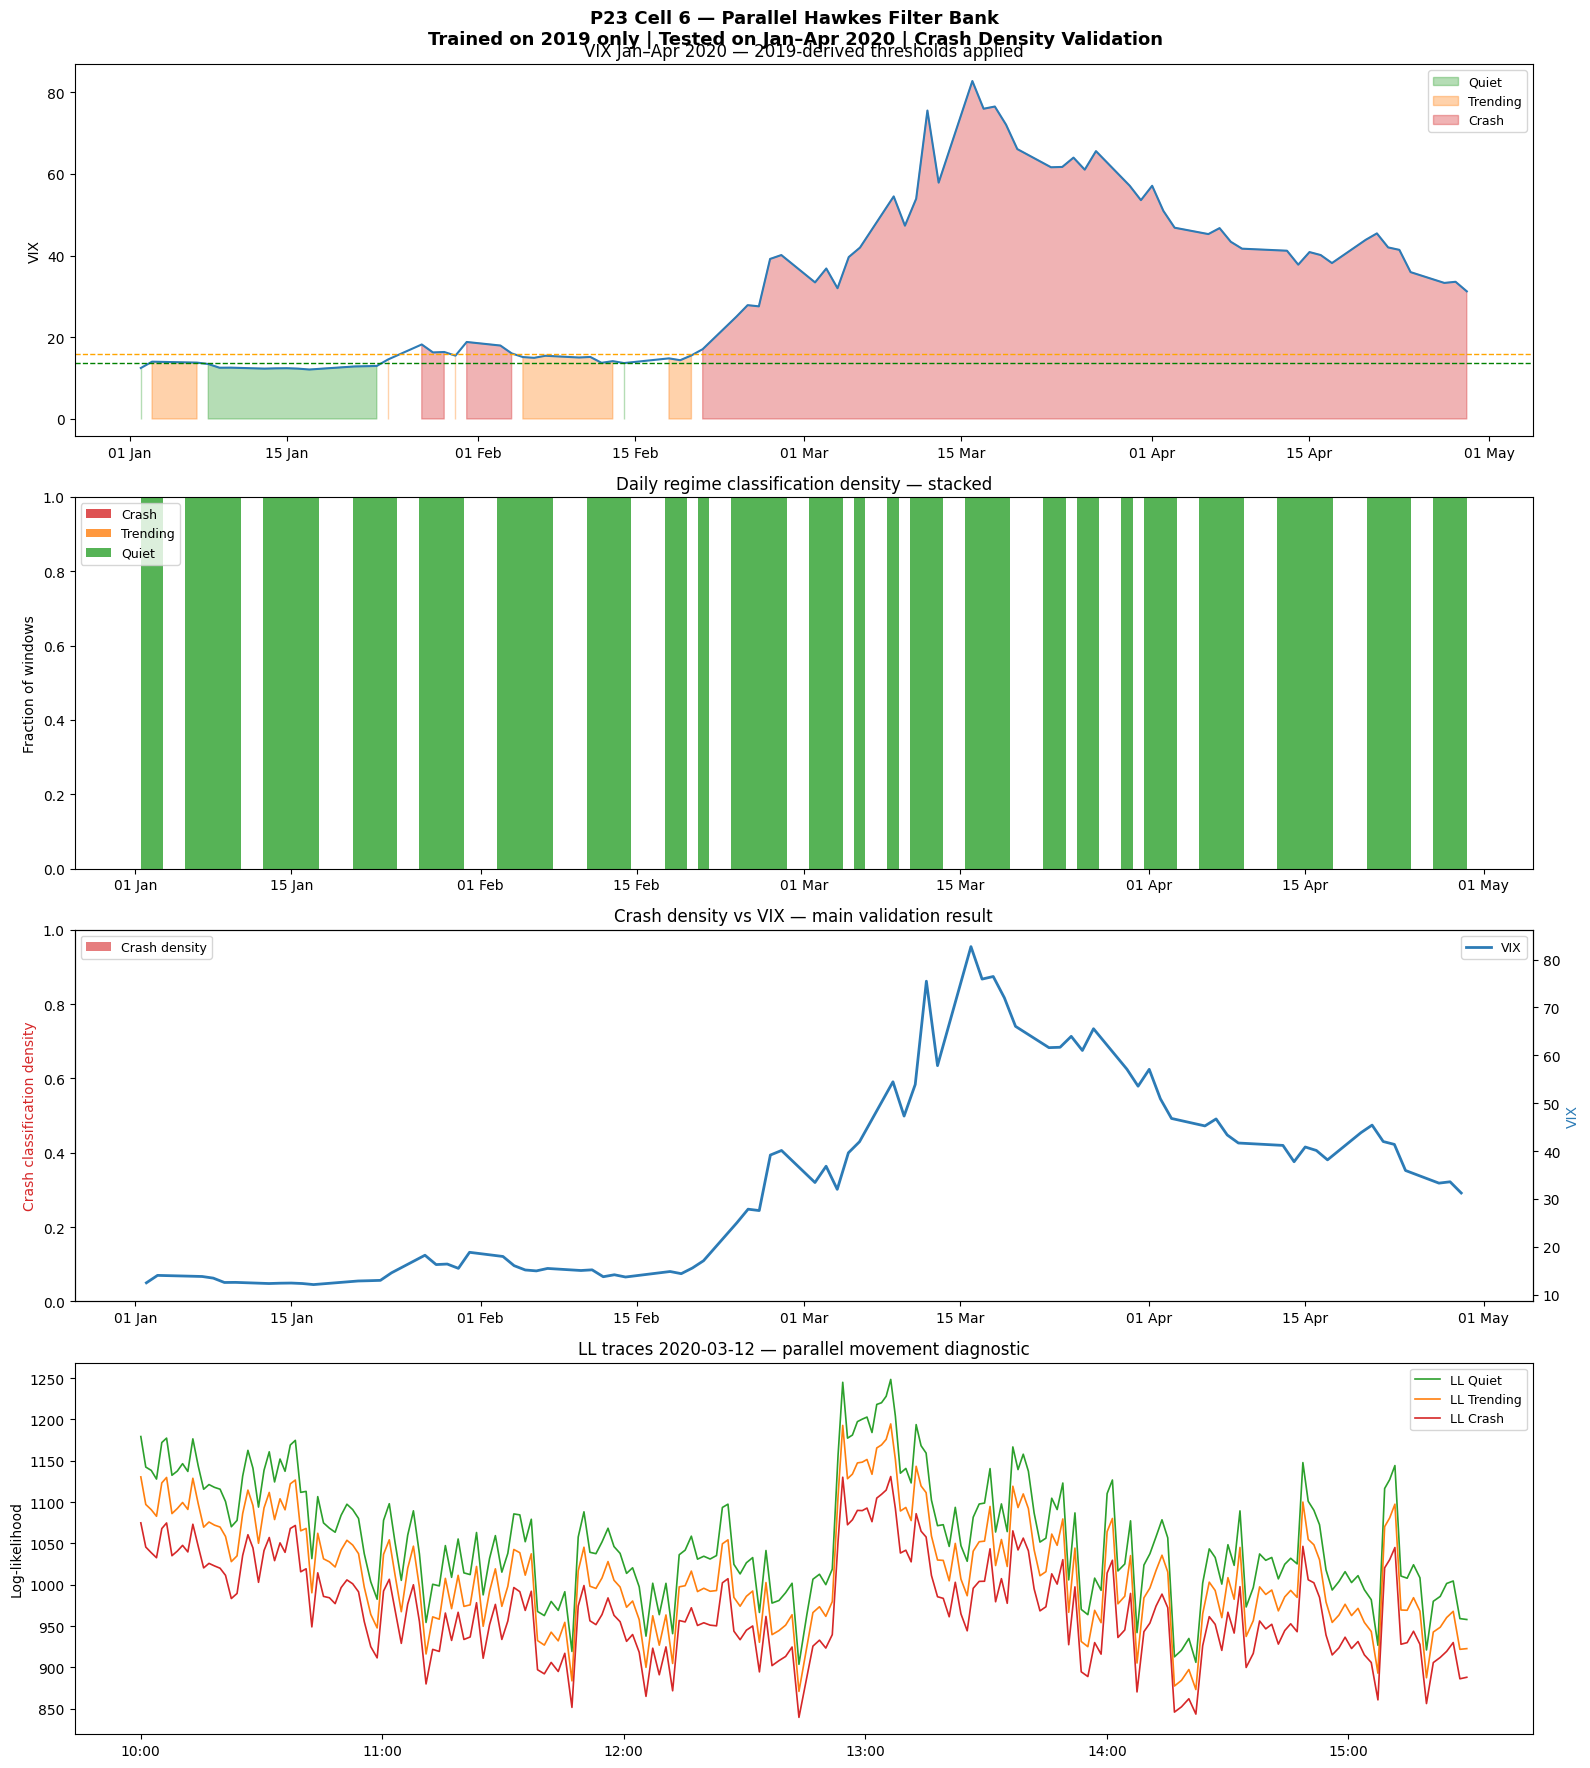


✅ Cell 6 complete.


In [15]:
# --- Crash density aggregation (P16 method — correct validation) ---
print("\nCrash density aggregation...")

results_df["date"] = results_df["ts"].dt.date

# Per-day: fraction of windows predicting each regime
daily_pred = (results_df.groupby(["date","pred_regime"])
              .size()
              .unstack(fill_value=0))

for regime in ["Quiet","Trending","Crash"]:
    if regime not in daily_pred.columns:
        daily_pred[regime] = 0

daily_pred["total"]         = daily_pred.sum(axis=1)
daily_pred["crash_density"] = daily_pred["Crash"]   / daily_pred["total"]
daily_pred["quiet_density"] = daily_pred["Quiet"]   / daily_pred["total"]
daily_pred["trend_density"] = daily_pred["Trending"] / daily_pred["total"]
daily_pred.index = pd.to_datetime(daily_pred.index)

print(f"\nDaily crash density stats:")
print(f"  mean  : {daily_pred['crash_density'].mean():.3f}")
print(f"  max   : {daily_pred['crash_density'].max():.3f}")
print(f"  days with crash_density > 0.5 : "
      f"{(daily_pred['crash_density'] > 0.5).sum()}")

# --- 4-panel visualisation ---
colors = {"Quiet":"#2ca02c","Trending":"#ff7f0e","Crash":"#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle(
    "P23 Cell 6 — Parallel Hawkes Filter Bank\n"
    "Trained on 2019 only | Tested on Jan–Apr 2020 | Crash Density Validation",
    fontsize=13, fontweight='bold'
)

# Panel 1 — VIX with 2019-derived thresholds
ax = axes[0]
for regime, col in colors.items():
    mask = vix_test["regime"] == regime
    ax.fill_between(vix_test.index, vix_test["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix_test.index, vix_test["vix"], color="#2c7bb6", linewidth=1.5)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.set_ylabel("VIX")
ax.set_title("VIX Jan–Apr 2020 — 2019-derived thresholds applied")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 2 — stacked daily density (all three regimes)
ax = axes[1]
ax.bar(daily_pred.index, daily_pred["crash_density"],
       color="#d62728", alpha=0.8, width=1, label="Crash")
ax.bar(daily_pred.index, daily_pred["trend_density"],
       bottom=daily_pred["crash_density"],
       color="#ff7f0e", alpha=0.8, width=1, label="Trending")
ax.bar(daily_pred.index, daily_pred["quiet_density"],
       bottom=daily_pred["crash_density"]+daily_pred["trend_density"],
       color="#2ca02c", alpha=0.8, width=1, label="Quiet")
ax.set_ylabel("Fraction of windows")
ax.set_ylim(0, 1)
ax.set_title("Daily regime classification density — stacked")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 3 — crash density vs VIX overlay (main result)
ax  = axes[2]
ax2 = ax.twinx()
ax.bar(daily_pred.index, daily_pred["crash_density"],
       width=pd.Timedelta("1D"), color="#d62728",
       alpha=0.6, label="Crash density")
ax.set_ylabel("Crash classification density", color="#d62728")
ax.set_ylim(0, 1)
ax2.plot(vix_test.index, vix_test["vix"],
         color="#2c7bb6", linewidth=2, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Crash density vs VIX — main validation result")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left",  fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 4 — LL traces for one day showing parallel movement
ax = axes[3]
# Pick a crash day — mid March
sample_date = pd.Timestamp("2020-03-12").date()
sample = results_df[results_df["ts"].dt.date == sample_date]
if len(sample) > 0:
    ax.plot(sample["ts"], sample["ll_quiet"],
            color="#2ca02c", label="LL Quiet",    linewidth=1.2)
    ax.plot(sample["ts"], sample["ll_trending"],
            color="#ff7f0e", label="LL Trending", linewidth=1.2)
    ax.plot(sample["ts"], sample["ll_crash"],
            color="#d62728", label="LL Crash",    linewidth=1.2)
    ax.set_title(f"LL traces {sample_date} — parallel movement diagnostic")
    ax.set_ylabel("Log-likelihood")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell6_filterbank.png", dpi=150)
plt.show()

print("\n✅ Cell 6 complete.")

Compiling numba kernels... done ✅

Initial parameters (from 2019 training):
  Quiet     : µ=0.4606  α=0.1005  β=0.1207  n=0.8328
  Trending  : µ=0.4428  α=0.0750  β=0.0828  n=0.9062
  Crash     : µ=1.1278  α=0.0423  β=0.0542  n=0.7798

Trading days in test window: 73
  2020-01-02  winner=Quiet      crash_d=0.00  µ_new=0.6021  vix=Quiet  ✓
  2020-01-03  winner=Quiet      crash_d=0.00  µ_new=0.4485  vix=Trending  ✗
  2020-01-06  winner=Trending   crash_d=0.00  µ_new=0.4444  vix=Trending  ✓
  2020-01-07  winner=Quiet      crash_d=0.00  µ_new=0.3580  vix=Trending  ✗
  2020-01-08  winner=Crash      crash_d=0.87  µ_new=0.3969  vix=Quiet  ✗
  2020-01-09  winner=Trending   crash_d=0.00  µ_new=0.8266  vix=Quiet  ✗
  2020-01-10  winner=Trending   crash_d=0.00  µ_new=1.2460  vix=Quiet  ✗
  2020-01-13  winner=Trending   crash_d=0.00  µ_new=1.1766  vix=Quiet  ✗
  2020-01-14  winner=Trending   crash_d=0.00  µ_new=0.4537  vix=Quiet  ✗
  2020-01-15  winner=Trending   crash_d=0.00  µ_new=3.6489  vix=Qu

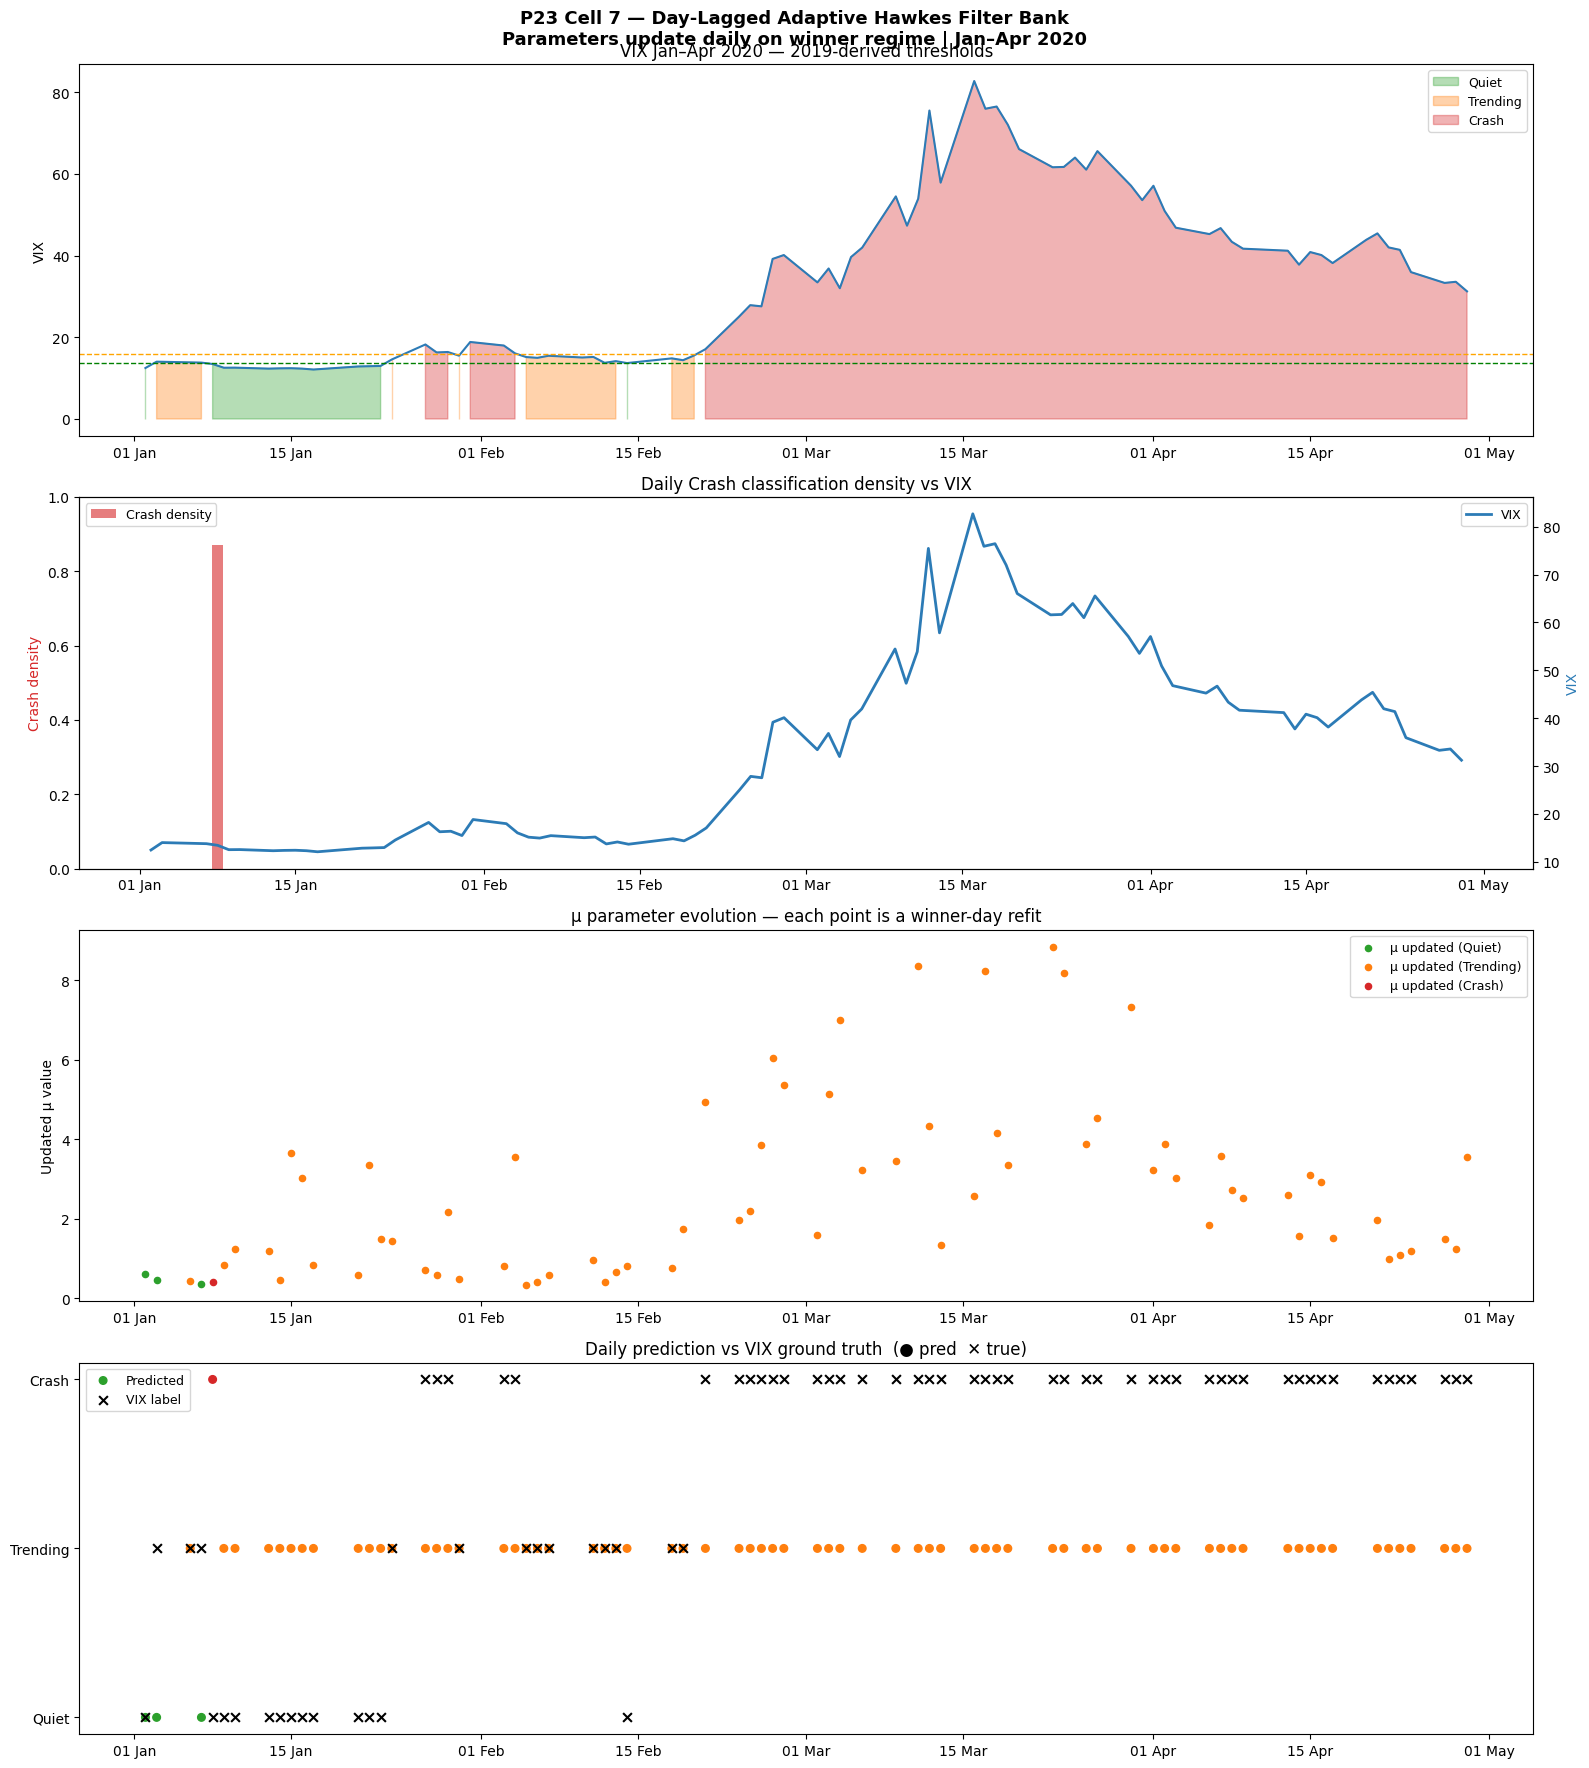


✅ Cell 7 complete.


In [17]:
# ============================================================
# PROTOTYPE 23 — Cell 7
# Day-Lagged Adaptive Hawkes Filter Bank
# Parameters update daily — winner regime only
# No future data used. Fully causal.
# ============================================================

from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

@njit
def hawkes_ll_window(mu, alpha, beta, dt_window):
    n        = len(dt_window)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt_window[i]
        decay     = np.exp(-beta * dt_window[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return -1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return ll

@njit
def hawkes_nll_lam(mu, alpha, beta, dt):
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return 1e10
    if alpha / beta >= 0.98:
        return 1e10
    n        = len(dt)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt[i]
        decay     = np.exp(-beta * dt[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return 1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return -ll

# Warm up
print("Compiling numba kernels... ", end="")
_d = np.array([0.1, 0.2, 0.15, 0.3])
hawkes_ll_window(1.0, 0.1, 0.2, _d)
hawkes_nll_lam(1.0, 0.1, 0.2, _d)
print("done ✅")

def fit_day(dt_arr, regime, n_restarts=5):
    """Single-day refit — 5 restarts only (speed over exhaustiveness)."""
    best_nll    = np.inf
    best_params = None
    bounds      = [(1e-4, 50.0), (1e-4, 2.0), (1e-4, 20.0)]

    for _ in range(n_restarts):
        mu0    = np.random.uniform(0.1, 10.0)
        alpha0 = np.random.uniform(0.01, 0.5)
        if regime == "Crash":
            n0 = np.random.uniform(0.3, 0.80)
        elif regime == "Trending":
            n0 = np.random.uniform(0.4, 0.85)
        else:
            n0 = np.random.uniform(0.4, 0.90)
        beta0 = alpha0 / n0

        try:
            res = minimize(
                lambda x: hawkes_nll_lam(x[0], x[1], x[2], dt_arr),
                [mu0, alpha0, beta0],
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 1000, "ftol": 1e-10}
            )
            mu_c, alpha_c, beta_c = res.x
            if alpha_c / beta_c >= 0.98:
                continue
            if res.fun < best_nll:
                best_nll    = res.fun
                best_params = (mu_c, alpha_c, beta_c)
        except Exception:
            continue

    return best_params

# --- Initial parameters from Cell 5 (2019 training) ---
params = {
    "Quiet":    [MU_Q,  ALPHA_Q,  BETA_Q],
    "Trending": [MU_T,  ALPHA_T,  BETA_T],
    "Crash":    [MU_C,  ALPHA_C,  BETA_C],
}

print("\nInitial parameters (from 2019 training):")
for r, p in params.items():
    print(f"  {r:<10}: µ={p[0]:.4f}  α={p[1]:.4f}  β={p[2]:.4f}  "
          f"n={p[1]/p[2]:.4f}")

# --- Day-by-day adaptive loop ---
WINDOW_SIZE = 1000

trading_days = sorted(raw_test["ts"].dt.date.unique())
print(f"\nTrading days in test window: {len(trading_days)}")

daily_log = []       # one row per day
all_windows = []     # one row per 1000-tick window

for day in trading_days:
    day_df = raw_test[raw_test["ts"].dt.date == day].copy()

    if len(day_df) < WINDOW_SIZE:
        print(f"  {day}  SKIP ({len(day_df)} ticks)")
        continue

    # Apply jitter
    np.random.seed(int(str(day).replace("-","")) % 100003)
    dt_day = day_df["dt"].values.astype(np.float64)
    dt_day = dt_day + np.random.uniform(0.0, 0.049, size=len(dt_day))
    ts_day = day_df["ts"].values

    # --- Classify all windows in this day ---
    n_windows = len(dt_day) // WINDOW_SIZE
    day_preds = []

    for w in range(n_windows):
        start  = w * WINDOW_SIZE
        end    = start + WINDOW_SIZE
        dt_win = dt_day[start:end]
        ts_mid = ts_day[start + WINDOW_SIZE // 2]

        ll_q = hawkes_ll_window(*params["Quiet"],    dt_win)
        ll_t = hawkes_ll_window(*params["Trending"], dt_win)
        ll_c = hawkes_ll_window(*params["Crash"],    dt_win)

        pred = ["Quiet","Trending","Crash"][np.argmax([ll_q, ll_t, ll_c])]
        day_preds.append(pred)

        all_windows.append({
            "ts":          pd.Timestamp(ts_mid),
            "date":        day,
            "pred_regime": pred,
            "ll_quiet":    ll_q,
            "ll_trending": ll_t,
            "ll_crash":    ll_c,
        })

    # --- Daily majority vote ---
    from collections import Counter
    vote    = Counter(day_preds)
    winner  = vote.most_common(1)[0][0]
    total_w = sum(vote.values())
    crash_d = vote.get("Crash", 0) / total_w

    # --- Refit winner engine on today's full ticks ---
    new_params = fit_day(dt_day, regime=winner, n_restarts=5)

    updated = False
    if new_params is not None:
        mu_n, alpha_n, beta_n = new_params
        params[winner] = [mu_n, alpha_n, beta_n]
        updated = True

    # VIX label for this day
    day_ts = pd.Timestamp(day)
    if day_ts in vix_test.index:
        vl = vix_test.loc[day_ts, "vix"]
        vix_label = ("Quiet" if vl < Q_MAX
                    else "Trending" if vl < T_MAX
                    else "Crash")

    daily_log.append({
        "date":         day,
        "winner":       winner,
        "crash_density":crash_d,
        "n_windows":    total_w,
        "params_updated": updated,
        "new_mu":       params[winner][0] if updated else np.nan,
        "vix_label":    vix_label,
        "correct":      winner == vix_label,
    })

    print(f"  {day}  winner={winner:<10} crash_d={crash_d:.2f}"
          f"  µ_new={params[winner][0]:.4f}"
          f"  vix={vix_label}"
          f"  {'✓' if winner==vix_label else '✗'}")

# --- Results ---
log_df  = pd.DataFrame(daily_log)
log_df["date"] = pd.to_datetime(log_df["date"])

wins_df = log_df[log_df["vix_label"] != "N/A"].copy()
overall = wins_df["correct"].mean()

print(f"\n{'='*55}")
print(f"  ADAPTIVE FILTER BANK RESULTS")
print(f"{'='*55}")
print(f"\n  Overall daily accuracy : {overall:.1%}")
print(f"\n  Per-regime accuracy:")
for regime in ["Quiet","Trending","Crash"]:
    sub = wins_df[wins_df["vix_label"] == regime]
    if len(sub) == 0:
        continue
    acc = sub["correct"].mean()
    print(f"    {regime:<10}: {acc:.1%}  ({len(sub)} days)")

# --- Visualise ---
colors = {"Quiet":"#2ca02c","Trending":"#ff7f0e","Crash":"#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle(
    "P23 Cell 7 — Day-Lagged Adaptive Hawkes Filter Bank\n"
    "Parameters update daily on winner regime | Jan–Apr 2020",
    fontsize=13, fontweight='bold'
)

# Panel 1 — VIX
ax = axes[0]
for regime, col in colors.items():
    mask = vix_test["regime"] == regime
    ax.fill_between(vix_test.index, vix_test["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix_test.index, vix_test["vix"], color="#2c7bb6", linewidth=1.5)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.set_ylabel("VIX")
ax.set_title("VIX Jan–Apr 2020 — 2019-derived thresholds")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 2 — crash density vs VIX
ax  = axes[1]
ax2 = ax.twinx()
ax.bar(log_df["date"], log_df["crash_density"],
       width=pd.Timedelta("1D"), color="#d62728",
       alpha=0.6, label="Crash density")
ax.set_ylabel("Crash density", color="#d62728")
ax.set_ylim(0, 1)
ax2.plot(vix_test.index, vix_test["vix"],
         color="#2c7bb6", linewidth=2, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Daily Crash classification density vs VIX")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left",  fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 3 — µ evolution per regime over time
ax = axes[2]
win_df = pd.DataFrame(all_windows)
win_df["date"] = pd.to_datetime(win_df["date"])

for regime, col in colors.items():
    sub = log_df[log_df["winner"] == regime]
    if len(sub) > 0:
        ax.scatter(sub["date"], sub["new_mu"],
                   color=col, s=20, label=f"µ updated ({regime})", zorder=3)

ax.set_ylabel("Updated µ value")
ax.set_title("µ parameter evolution — each point is a winner-day refit")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 4 — daily prediction vs VIX label
ax = axes[3]
pred_colors = [colors.get(r, "gray") for r in log_df["winner"]]
ax.scatter(log_df["date"], log_df["winner"],
           c=pred_colors, s=30, zorder=3, label="Predicted")
vix_labels_plot = wins_df["vix_label"].values
ax.scatter(wins_df["date"], vix_labels_plot,
           marker="x", color="black", s=40, zorder=4, label="VIX label")
ax.set_title("Daily prediction vs VIX ground truth  (● pred  ✕ true)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell7_adaptive.png", dpi=150)
plt.show()

print("\n✅ Cell 7 complete.")

Compiling numba kernels... done ✅

Initial parameters (from 2019 training):
  Quiet     : µ=0.4606  α=0.1005  β=0.1207  n=0.8328
  Trending  : µ=0.4428  α=0.0750  β=0.0828  n=0.9062
  Crash     : µ=1.1278  α=0.0423  β=0.0542  n=0.7798
  2020-01-02  winner=Quiet      crash_d=0.00  µ=0.6021  vix=Quiet  ✓
  2020-01-03  winner=Quiet      crash_d=0.00  µ=0.4491  vix=Trending  ✗
  2020-01-06  winner=Quiet      crash_d=0.00  µ=0.4789  vix=Trending  ✗
  2020-01-07  winner=Trending   crash_d=0.00  µ=0.4382  vix=Trending  ✓
  2020-01-08  winner=Crash      crash_d=0.68  µ=0.8667  vix=Quiet  ✗
  [2020-01-09] FORCED EXPLORATION — refitting all engines
    Quiet: µ=0.4789  α=0.0558  β=0.0646  n=0.8634
    Trending: µ=0.4382  α=0.0542  β=0.0610  n=0.8892
    Crash: µ=0.8672  α=0.0552  β=0.0682  n=0.8095
  2020-01-09  winner=Crash      crash_d=1.00  µ=3.6836  vix=Quiet  ✗
  2020-01-10  winner=Crash      crash_d=0.80  µ=0.5230  vix=Quiet  ✗
  2020-01-13  winner=Crash      crash_d=1.00  µ=0.3955  vix=Qu

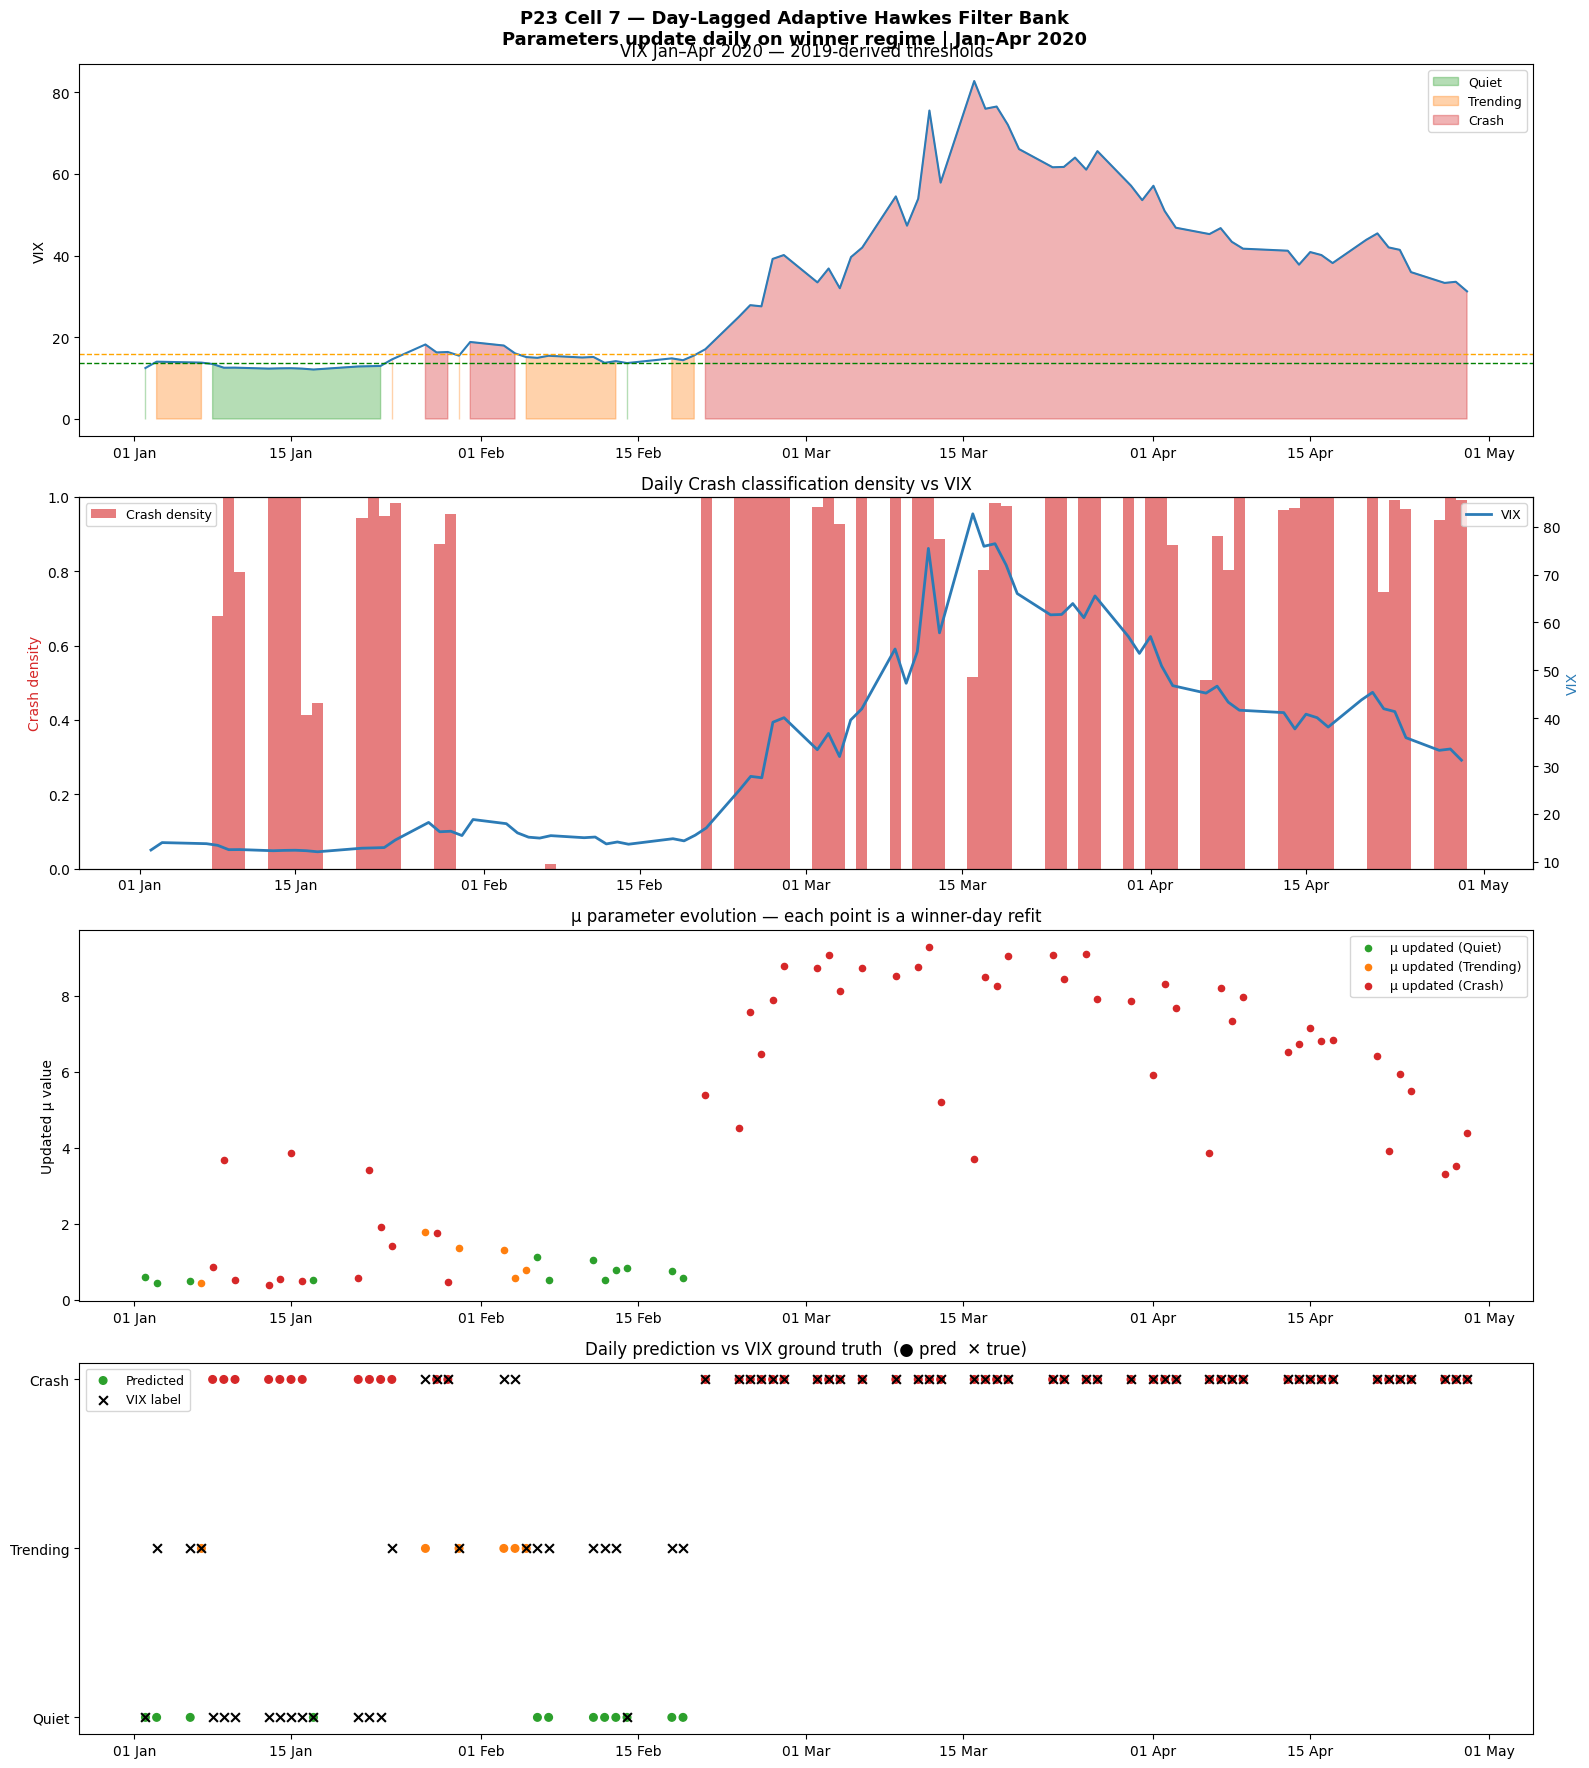


✅ Cell 7 complete.


In [18]:
# ============================================================
# PROTOTYPE 23 — Cell 7
# Day-Lagged Adaptive Hawkes Filter Bank
# Parameters update daily — winner regime only
# No future data used. Fully causal.
# ============================================================

from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

@njit
def hawkes_ll_window(mu, alpha, beta, dt_window):
    n        = len(dt_window)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt_window[i]
        decay     = np.exp(-beta * dt_window[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return -1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return ll

@njit
def hawkes_nll_lam(mu, alpha, beta, dt):
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return 1e10
    if alpha / beta >= 0.98:
        return 1e10
    n        = len(dt)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0
    for i in range(n):
        T        += dt[i]
        decay     = np.exp(-beta * dt[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return 1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha
    ll -= (mu * T + (alpha / beta) * n)
    return -ll

# Warm up
print("Compiling numba kernels... ", end="")
_d = np.array([0.1, 0.2, 0.15, 0.3])
hawkes_ll_window(1.0, 0.1, 0.2, _d)
hawkes_nll_lam(1.0, 0.1, 0.2, _d)
print("done ✅")

def fit_day(dt_arr, regime, n_restarts=5):
    """Single-day refit — 5 restarts only (speed over exhaustiveness)."""
    best_nll    = np.inf
    best_params = None
    bounds      = [(1e-4, 50.0), (1e-4, 2.0), (1e-4, 20.0)]

    for _ in range(n_restarts):
        mu0    = np.random.uniform(0.1, 10.0)
        alpha0 = np.random.uniform(0.01, 0.5)
        if regime == "Crash":
            n0 = np.random.uniform(0.3, 0.80)
        elif regime == "Trending":
            n0 = np.random.uniform(0.4, 0.85)
        else:
            n0 = np.random.uniform(0.4, 0.90)
        beta0 = alpha0 / n0

        try:
            res = minimize(
                lambda x: hawkes_nll_lam(x[0], x[1], x[2], dt_arr),
                [mu0, alpha0, beta0],
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 1000, "ftol": 1e-10}
            )
            mu_c, alpha_c, beta_c = res.x
            if alpha_c / beta_c >= 0.98:
                continue
            if res.fun < best_nll:
                best_nll    = res.fun
                best_params = (mu_c, alpha_c, beta_c)
        except Exception:
            continue

    return best_params

# --- Initial parameters from Cell 5 (2019 training) ---
params = {
    "Quiet":    [MU_Q,  ALPHA_Q,  BETA_Q],
    "Trending": [MU_T,  ALPHA_T,  BETA_T],
    "Crash":    [MU_C,  ALPHA_C,  BETA_C],
}

print("\nInitial parameters (from 2019 training):")
for r, p in params.items():
    print(f"  {r:<10}: µ={p[0]:.4f}  α={p[1]:.4f}  β={p[2]:.4f}  "
          f"n={p[1]/p[2]:.4f}")

# --- Day-by-day adaptive loop ---
# --- Day-lagged adaptive loop with forced exploration ---
WINDOW_SIZE    = 1000
EXPLORE_EVERY  = 5    # refit all engines from their last-seen buffer

# Buffer: store last day's ticks for each regime
last_seen_ticks = {
    "Quiet":    regime_ticks["Quiet"].tail(5000)["dt"].values.astype(np.float64),
    "Trending": regime_ticks["Trending"].tail(5000)["dt"].values.astype(np.float64),
    "Crash":    regime_ticks["Crash"].tail(5000)["dt"].values.astype(np.float64),
}

# Apply jitter to buffers once
for r in ["Quiet","Trending","Crash"]:
    np.random.seed(42)
    last_seen_ticks[r] = (last_seen_ticks[r] +
                          np.random.uniform(0.0, 0.049,
                          size=len(last_seen_ticks[r])))

trading_days = sorted(raw_test["ts"].dt.date.unique())
day_counter  = 0
daily_log    = []
all_windows  = []

for day in trading_days:
    day_df = raw_test[raw_test["ts"].dt.date == day].copy()
    if len(day_df) < WINDOW_SIZE:
        continue

    # Jitter
    np.random.seed(int(str(day).replace("-","")) % 100003)
    dt_day = day_df["dt"].values.astype(np.float64)
    dt_day = dt_day + np.random.uniform(0.0, 0.049, size=len(dt_day))
    ts_day = day_df["ts"].values

    # --- Forced exploration: refit all three from their buffers ---
    if day_counter % EXPLORE_EVERY == 0 and day_counter > 0:
        print(f"  [{day}] FORCED EXPLORATION — refitting all engines")
        for regime in ["Quiet","Trending","Crash"]:
            buf = last_seen_ticks[regime]
            new_p = fit_day(buf, regime=regime, n_restarts=5)
            if new_p is not None:
                params[regime] = list(new_p)
                print(f"    {regime}: µ={new_p[0]:.4f}  α={new_p[1]:.4f}"
                      f"  β={new_p[2]:.4f}  n={new_p[1]/new_p[2]:.4f}")

    # --- Classify windows ---
    n_windows = len(dt_day) // WINDOW_SIZE
    day_preds = []

    for w in range(n_windows):
        start  = w * WINDOW_SIZE
        end    = start + WINDOW_SIZE
        dt_win = dt_day[start:end]
        ts_mid = ts_day[start + WINDOW_SIZE // 2]

        ll_q = hawkes_ll_window(*params["Quiet"],    dt_win)
        ll_t = hawkes_ll_window(*params["Trending"], dt_win)
        ll_c = hawkes_ll_window(*params["Crash"],    dt_win)

        pred = ["Quiet","Trending","Crash"][np.argmax([ll_q, ll_t, ll_c])]
        day_preds.append(pred)

        all_windows.append({
            "ts":          pd.Timestamp(ts_mid),
            "date":        day,
            "pred_regime": pred,
            "ll_quiet":    ll_q,
            "ll_trending": ll_t,
            "ll_crash":    ll_c,
        })

    # --- Daily majority vote ---
    from collections import Counter
    vote    = Counter(day_preds)
    winner  = vote.most_common(1)[0][0]
    total_w = sum(vote.values())
    crash_d = vote.get("Crash", 0) / total_w

    # --- Update winner buffer and refit ---
    last_seen_ticks[winner] = dt_day[:min(len(dt_day), 50000)]
    new_params = fit_day(dt_day[:min(len(dt_day), 50000)],
                         regime=winner, n_restarts=5)
    updated = False
    if new_params is not None:
        params[winner] = list(new_params)
        updated = True

    # --- VIX label ---
    day_ts    = pd.Timestamp(day)
    vix_label = "N/A"
    if day_ts in vix_test.index:
        vl = vix_test.loc[day_ts, "vix"]
        vix_label = ("Quiet"    if vl < Q_MAX else
                     "Trending" if vl < T_MAX else "Crash")

    correct = (winner == vix_label)
    daily_log.append({
        "date":          day,
        "winner":        winner,
        "crash_density": crash_d,
        "n_windows":     total_w,
        "new_mu":        params[winner][0] if updated else np.nan,
        "vix_label":     vix_label,
        "correct":       correct,
    })

    print(f"  {day}  winner={winner:<10} crash_d={crash_d:.2f}"
          f"  µ={params[winner][0]:.4f}"
          f"  vix={vix_label}"
          f"  {'✓' if correct else '✗'}")

    day_counter += 1

# --- Results ---
log_df  = pd.DataFrame(daily_log)
log_df["date"] = pd.to_datetime(log_df["date"])

wins_df = log_df[log_df["vix_label"] != "N/A"].copy()
overall = wins_df["correct"].mean()

print(f"\n{'='*55}")
print(f"  ADAPTIVE FILTER BANK RESULTS")
print(f"{'='*55}")
print(f"\n  Overall daily accuracy : {overall:.1%}")
print(f"\n  Per-regime accuracy:")
for regime in ["Quiet","Trending","Crash"]:
    sub = wins_df[wins_df["vix_label"] == regime]
    if len(sub) == 0:
        continue
    acc = sub["correct"].mean()
    print(f"    {regime:<10}: {acc:.1%}  ({len(sub)} days)")

# --- Visualise ---
colors = {"Quiet":"#2ca02c","Trending":"#ff7f0e","Crash":"#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle(
    "P23 Cell 7 — Day-Lagged Adaptive Hawkes Filter Bank\n"
    "Parameters update daily on winner regime | Jan–Apr 2020",
    fontsize=13, fontweight='bold'
)

# Panel 1 — VIX
ax = axes[0]
for regime, col in colors.items():
    mask = vix_test["regime"] == regime
    ax.fill_between(vix_test.index, vix_test["vix"],
                    where=mask, alpha=0.35, color=col, label=regime)
ax.plot(vix_test.index, vix_test["vix"], color="#2c7bb6", linewidth=1.5)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.set_ylabel("VIX")
ax.set_title("VIX Jan–Apr 2020 — 2019-derived thresholds")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 2 — crash density vs VIX
ax  = axes[1]
ax2 = ax.twinx()
ax.bar(log_df["date"], log_df["crash_density"],
       width=pd.Timedelta("1D"), color="#d62728",
       alpha=0.6, label="Crash density")
ax.set_ylabel("Crash density", color="#d62728")
ax.set_ylim(0, 1)
ax2.plot(vix_test.index, vix_test["vix"],
         color="#2c7bb6", linewidth=2, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Daily Crash classification density vs VIX")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left",  fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 3 — µ evolution per regime over time
ax = axes[2]
win_df = pd.DataFrame(all_windows)
win_df["date"] = pd.to_datetime(win_df["date"])

for regime, col in colors.items():
    sub = log_df[log_df["winner"] == regime]
    if len(sub) > 0:
        ax.scatter(sub["date"], sub["new_mu"],
                   color=col, s=20, label=f"µ updated ({regime})", zorder=3)

ax.set_ylabel("Updated µ value")
ax.set_title("µ parameter evolution — each point is a winner-day refit")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 4 — daily prediction vs VIX label
ax = axes[3]
pred_colors = [colors.get(r, "gray") for r in log_df["winner"]]
ax.scatter(log_df["date"], log_df["winner"],
           c=pred_colors, s=30, zorder=3, label="Predicted")
vix_labels_plot = wins_df["vix_label"].values
ax.scatter(wins_df["date"], vix_labels_plot,
           marker="x", color="black", s=40, zorder=4, label="VIX label")
ax.set_title("Daily prediction vs VIX ground truth  (● pred  ✕ true)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.tight_layout()
plt.savefig(OUT_DIR / "p23_cell7_adaptive.png", dpi=150)
plt.show()

print("\n✅ Cell 7 complete.")